# Predicting Type 2 Diabetes Risk Using BRFSS 2023

This project develops an interpretable machine-learning workflow for estimating Type 2 diabetes risk using selected Behavioral Risk Factor Surveillance System (BRFSS) 2023 variables. The workflow covers data cleaning, exploratory data analysis, baseline and tree-based models, model comparison, feature interpretation, and public-health recommendations.


## Apex Project Team

| Name | GitHub | Role |
|------|--------|------|
| Stephen Mwaura | **@S-Mwaura** | Project Lead · Modeling |
| Angela Masaki | **@MoonwaMasaki** | Data Engineering · Exploratory Data Analysis (EDA) |
| Diana Byegon | **@byegond-beep** | Feature Engineering · Model Evaluation |
| Kevin Kisengu | **@K-OK27** | Model Explainability (SHAP & LIME) |
| Orandi Felix | **@Orandifelix** | Documentation · Modeling |

## 1. Business Understanding

Type 2 Diabetes Mellitus (T2DM) is a major public health challenge affecting over 500 million people worldwide and is one of the fastest-growing chronic diseases globally (International Diabetes Federation, 2021) which contributes to increased healthcare costs, reduced quality of life, and a higher risk of complications such as cardiovascular disease, kidney disease, and stroke. Early identification of individuals at high risk enables healthcare providers to implement preventive interventions, promote healthy lifestyle changes, and improve disease management. This project develops a machine learning model to predict the likelihood of Type 2 Diabetes using demographic, behavioral, and clinical risk factors collected through the Behavioral Risk Factor Surveillance System (BRFSS) 2023 survey

### Problem Statement

Early detection of Type 2 Diabetes remains a challenge because many individuals are undiagnosed until complications develop. Traditional screening methods may not efficiently identify high-risk individuals across large populations. Therefore, there is a need for a predictive model that can accurately classify individuals as having diabetes or not using readily available health survey data. Such a model can support healthcare professionals in prioritizing screening efforts and designing targeted prevention programs.

### Objectives

- Clean and prepare BRFSS survey variables for machine learning.
- Explore demographic, behavioral, and clinical factors associated with diabetes.
- Train and compare Logistic Regression, Decision Tree, Random Forest, and XGBoost classifiers.
- Identify the most influential predictors and translate them into actionable recommendations.
- To implement SHAP and LIME for model explainability
- To develop an interactive dashboard for disease risk prediction and visualization

### Stakeholders
#### Primary Stakeholders
- Clinicians and other healthcare providers
- Patients and individuals at risk of T2DM
- Public health agencies and health promotion programs

#### Secondary Stakeholders
- Researchers and academic institutions
- Health insurance organizations
- Policy makers focused on reducing diabetes prevalence
- NGOs and community health organizations

### Success Metrics

Because diabetes screening is a risk-identification problem, the priority is not only overall accuracy. The key metrics are:

- At least one machine learning model achieves an **ROC-AUC** of ≥80% on the test set.
- **ROC-AUC:** overall discrimination between diabetic and non-diabetic respondents.
- **Recall for diabetes:** ability to identify respondents with diabetes.
- **Precision for diabetes:** share of predicted diabetes cases that are truly diabetes cases.
- **F1-score:** balance between precision and recall.
- **SHAP and LIME** explanations are successfully generated and visualized
- The **Streamlit** dashboard runs without errors and displays all required outputs


## 2. Dataset

### Dataset Overview

The project uses the Behavioral Risk Factor Surveillance System (BRFSS) 2023 dataset, a nationally representative health survey conducted annually by the Centers for Disease Control and Prevention (CDC). The dataset contains self-reported information on demographics, health conditions, lifestyle behaviors, and access to healthcare collected from U.S. adults through telephone interviews.

**Dataset Details:**
- Dataset: [BRFSS 2023](https://www.cdc.gov/brfss/annual_data/annual_2023.html)
- Observations: 433,323 respondents
- Features: 350 variables
- Survey Type: Cross-sectional telephone survey





## 3. Import Required Libraries


In [84]:
# Data manipulation

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
# Model persistence
import joblib
# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer
# Set global settings for visualizations and pandas display options
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 4. Load Data


In [2]:
# Load the dataset
DATA_PATH = "CDC_LLCP2023.XPT"

df = pd.read_sas(DATA_PATH, format="xport")

# Display the first few rows of the dataset
df.head()


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,NUMADULT,RESPSLC1,LANDSEX2,LNDSXBRT,SAFETIME,CTELNUM1,CELLFON5,CADULT1,CELLSEX2,CELSXBRT,PVTRESD3,CCLGHOUS,CSTATE1,LANDLINE,HHADULT,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,PRIMINS1,PERSDOC3,MEDCOST1,CHECKUP1,EXERANY2,EXRACT12,EXEROFT1,EXERHMM1,EXRACT22,EXEROFT2,EXERHMM2,STRENGTH,BPHIGH6,BPMEDS1,CHOLCHK3,...,_PACAT3,_PAINDX3,_PA150R4,_PA300R4,_PA30023,_PASTRNG,_PAREC3,_PASTAE3,_RFHYPE6,_CHOLCH3,_RFCHOL3,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR2,_MRACE1,_HISPANC,_RACE,_RACEG21,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_SMOKER3,_RFSMOK3,_CURECI2,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV
0,1.0,1.0,b'03012023',b'03',b'01',b'2023',1100.0,b'2023000001',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,88.0,88.0,NaN,3.0,1.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,888.0,1.0,1.0,3.0,...,4.0,2.0,3.0,3.0,2.0,2.0,4.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,13.0,2.0,80.0,6.0,63.0,160.0,7802.0,3047.0,4.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,2.0,2.0,1.0,1.0,9.0
1,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000002',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,88.0,88.0,NaN,3.0,1.0,2.0,2.0,1.0,1.0,106.0,30.0,88.0,NaN,NaN,888.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,13.0,2.0,80.0,6.0,57.0,145.0,5987.0,2856.0,3.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
2,1.0,1.0,b'03082023',b'03',b'08',b'2023',1100.0,b'2023000003',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,6.0,2.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,205.0,15.0,88.0,NaN,NaN,205.0,1.0,1.0,2.0,...,9.0,9.0,9.0,9.0,9.0,2.0,9.0,9.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,13.0,2.0,80.0,6.0,64.0,163.0,5897.0,2231.0,2.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0
3,1.0,1.0,b'03062023',b'03',b'06',b'2023',1100.0,b'2023000004',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,88.0,88.0,3.0,1.0,2.0,3.0,1.0,1.0,103.0,30.0,88.0,NaN,NaN,888.0,3.0,NaN,3.0,...,9.0,1.0,1.0,9.0,9.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,12.0,2.0,78.0,6.0,66.0,168.0,7711.0,2744.0,3.0,2.0,1.0,3.0,9.0,4.0,1.0,1.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,1.0,1.0,1.0,9.0
4,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000005',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,88.0,88.0,NaN,3.0,1.0,2.0,1.0,1.0,1.0,102.0,45.0,8.0,107.0,100.0,888.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,12.0,2.0,76.0,6.0,68.0,173.0,7711.0,2585.0,3.0,2.0,1.0,3.0,5.0,4.0,1.0,1.0,1.0,7.000000e+00,1.0,4.700000e+01,1.0,2.0,1.0,2.0,1.0,1.0,2.0


In [3]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Columns: 350 entries, _STATE to _DRNKDRV
dtypes: float64(345), object(5)
memory usage: 1.1+ GB


> **Observation:** The dataset consists of **433,323 records** and **350 variables**, with most variables stored as numeric (`float64`) and a small number as object types. The dataset occupies approximately **1.1 GB** of memory, highlighting the importance of efficient preprocessing and feature selection prior to modeling.

In [4]:
# Summary statistics
df.describe(include="all")

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,NUMADULT,RESPSLC1,LANDSEX2,LNDSXBRT,SAFETIME,CTELNUM1,CELLFON5,CADULT1,CELLSEX2,CELSXBRT,PVTRESD3,CCLGHOUS,CSTATE1,LANDLINE,HHADULT,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,PRIMINS1,PERSDOC3,MEDCOST1,CHECKUP1,EXERANY2,EXRACT12,EXEROFT1,EXERHMM1,EXRACT22,EXEROFT2,EXERHMM2,STRENGTH,BPHIGH6,BPMEDS1,CHOLCHK3,...,_PACAT3,_PAINDX3,_PA150R4,_PA300R4,_PA30023,_PASTRNG,_PAREC3,_PASTAE3,_RFHYPE6,_CHOLCH3,_RFCHOL3,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR2,_MRACE1,_HISPANC,_RACE,_RACEG21,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_SMOKER3,_RFSMOK3,_CURECI2,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV
count,433323.000000,433323.000000,433323,433323,433323,433323,433323.000000,433323,4.333230e+05,88345.0,88345.000000,12.0,88345.000000,88346.000000,88345.000000,88330.000000,52386.000000,70473.000000,169.000000,344978.0,344978.0,344978.0,344978.0,344976.000000,2578.000000,344978.000000,1351.000000,344968.000000,344977.000000,344974.000000,433323.000000,433319.000000,433320.000000,433320.000000,252170.000000,433318.000000,433320.000000,433321.000000,433321.000000,433321.000000,325227.000000,323041.000000,323039.000000,323040.000000,228757.000000,228757.000000,433319.000000,433320.000000,176222.000000,433320.000000,...,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,381512.000000,428738.000000,433323.000000,433323.000000,433323.000000,430763.000000,433069.000000,433323.000000,433237.000000,433237.000000,433237.000000,433237.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,405324.000000,411182.000000,399172.000000,392788.000000,392788.000000,433323.000000,433323.00000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,433323.000000,4.333230e+05,433323.000000,4.333230e+05,433323.000000,170823.000000,170823.000000,403710.000000,433323.000000,433323.000000,433323.000000
unique,NaN,NaN,424,12,31,2,NaN,26444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,b'03212023',b'03',b'06',b'2023',NaN,b'2023000087',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2007,41255,15763,408012,NaN,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,30.486898,6.612273,NaN,NaN,NaN,NaN,1117.783963,NaN,2.023005e+09,1.0,1.000136,1.0,1.000011,2.000023,1.001505,1.796819,1.030294,1.626084,1.497041,1.0,1.0,1.0,1.0,1.519978,1.501939,1.003913,1.000740,1.053614,1.820188,2.960238,1.529723,2.629645,58.477843,58.022037,52.092521,10.865293,1.634589,1.933550,1.434567,1.265353,4.241213,154.081148,129.516322,29.835491,152.756619,139.719633,505.888565,2.208887,1.198380,2.652956,...,3.588863,2.442557,2.692961,3.260949,3.010544,1.841405,3.429917,2.886076,1.442104,1.635106,1.485149,1.915307,1.179944,1.168662,2.804945,1.668579,3.8535

### Observation
The summary statistics reveal considerable variation in the numerical variables, with many features containing BRFSS-specific coded values representing responses such as *Don't Know*, *Refused*, or *Not Applicable*. These coded values are meaningful within the survey but require recoding before statistical analysis or machine learning. The inspection also confirms that variables are measured on different scales, further highlighting the need for preprocessing prior to modeling.

In [5]:
# Missing values
df.isna().sum()

_STATE           0
FMONTH           0
IDATE            0
IMONTH           0
IDAY             0
             ...  
_PNEUMO3    262500
_AIDTST4     29613
_RFSEAT2         0
_RFSEAT3         0
_DRNKDRV         0
Length: 350, dtype: int64

### Observation

The missing value assessment shows that missingness is not uniformly distributed across the dataset. While many administrative and core survey variables are complete, several health-related and optional questionnaire variables contain substantial missing values because they were only asked to specific respondent groups or were subject to survey skip patterns.

These findings reinforce the need for careful feature selection and appropriate handling of missing values during data preparation. Rather than attempting to impute all missing values across the 350 variables, the project will focus on a subset of clinically relevant predictors, where missing data can be handled systematically before model development.

In [6]:
#Inspecting variable names
for i, col in enumerate(df.columns, start=1):
    print(f"{i:3}. {col}")

  1. _STATE
  2. FMONTH
  3. IDATE
  4. IMONTH
  5. IDAY
  6. IYEAR
  7. DISPCODE
  8. SEQNO
  9. _PSU
 10. CTELENM1
 11. PVTRESD1
 12. COLGHOUS
 13. STATERE1
 14. CELPHON1
 15. LADULT1
 16. NUMADULT
 17. RESPSLC1
 18. LANDSEX2
 19. LNDSXBRT
 20. SAFETIME
 21. CTELNUM1
 22. CELLFON5
 23. CADULT1
 24. CELLSEX2
 25. CELSXBRT
 26. PVTRESD3
 27. CCLGHOUS
 28. CSTATE1
 29. LANDLINE
 30. HHADULT
 31. SEXVAR
 32. GENHLTH
 33. PHYSHLTH
 34. MENTHLTH
 35. POORHLTH
 36. PRIMINS1
 37. PERSDOC3
 38. MEDCOST1
 39. CHECKUP1
 40. EXERANY2
 41. EXRACT12
 42. EXEROFT1
 43. EXERHMM1
 44. EXRACT22
 45. EXEROFT2
 46. EXERHMM2
 47. STRENGTH
 48. BPHIGH6
 49. BPMEDS1
 50. CHOLCHK3
 51. TOLDHI3
 52. CHOLMED3
 53. CVDINFR4
 54. CVDCRHD4
 55. CVDSTRK3
 56. ASTHMA3
 57. ASTHNOW
 58. CHCSCNC1
 59. CHCOCNC1
 60. CHCCOPD3
 61. ADDEPEV3
 62. CHCKDNY2
 63. HAVARTH4
 64. DIABETE4
 65. DIABAGE4
 66. MARITAL
 67. EDUCA
 68. RENTHOM1
 69. NUMHHOL4
 70. NUMPHON4
 71. CPDEMO1C
 72. VETERAN3
 73. EMPLOY1
 74. CHILDREN
 75.

## Variable Categories

The BRFSS questionnaire covers a broad range of health-related information. The variables can be grouped into several categories relevant to diabetes prediction.

| Category | Examples |
| :--- | :--- |
| **Demographics** | Age, Sex, Education, Income, Marital Status |
| **Lifestyle** | Smoking, Alcohol Consumption, Physical Activity |
| **Clinical Conditions** | High Blood Pressure, Cholesterol, BMI |
| **Medical History** | Heart Disease, Stroke, Kidney Disease |
| **Preventive Care** | Routine Checkups, Vaccinations |
| **Social Determinants** | Employment, Housing, Healthcare Access |
| **Derived CDC Variables** | BMI Categories, Physical Activity Index, Race Groups |

### Observation

The BRFSS 2023 dataset contains **350 variables**, representing a broad range of information collected through the survey. The large number of variables highlights the comprehensive nature of the dataset and provides a rich foundation for developing a predictive model. Variable selection and relevance assessment will be performed during the Data Preparation phase.

## 5. Target and Feature Selection


The target is `DIABETE4`, recoded as:

- `1`: respondent has diabetes.
- `0`: respondent does not have diabetes.

Respondents reporting prediabetes, gestational diabetes only, don't know/not sure, refused, or missing diabetes status are excluded from the supervised modeling target to keep the classification task focused on diagnosed diabetes versus no diabetes.

### Features Selected

The model uses 14 predictor variables selected because they are established risk factors for diabetes. They represent demographic, lifestyle, socioeconomic, health status, and clinical characteristics while avoiding variables that directly indicate diabetes diagnosis.

| Feature | Description | Reason for Inclusion |
|---------|-------------|---------------------|
| **`_BMI5`** | Body Mass Index | Higher BMI increases diabetes risk |
| **`_AGE80`** | Age | Diabetes risk increases with age |
| **`SEXVAR`** | Sex | Diabetes risk differs between males and females |
| **`_IMPRACE`** | Race/Ethnicity | Diabetes prevalence varies across population groups |
| **`GENHLTH`** | General Health | Poor health is associated with chronic disease |
| **`PHYSHLTH`** | Physical Health | Frequent poor health may indicate underlying illness |
| **`SMOKE100`** | Ever Smoked | Smoking increases diabetes risk |
| **`_TOTINDA`** | Physical Activity | Regular activity lowers diabetes risk |
| **`EDUCA`** | Education | Education influences health awareness and behaviors |
| **`INCOME3`** | Income | Income affects access to healthcare and healthy living |
| **`_RFHYPE6`** | Hypertension | High blood pressure commonly coexists with diabetes |
| **`_RFCHOL3`** | High Cholesterol | Linked to metabolic disorders and diabetes |
| **`CHCKDNY2`** | Kidney Disease | Strongly associated with diabetes |
| **`_MICHD`** | Heart Disease | Shares major risk factors with diabetes |

In [7]:
# Define the target variable
target = "DIABETE4"

# Define the features to be used in the model
features = [
    "_BMI5",       # Body mass index, stored as BMI * 100
    "_AGE80",      # Imputed age, top-coded at 80
    "SEXVAR",      # Sex
    "_IMPRACE",    # Imputed race/ethnicity
    "GENHLTH",     # General health
    "PHYSHLTH",    # Days physical health was not good in past 30 days
    "SMOKE100",    # Smoked at least 100 cigarettes in lifetime
    "_TOTINDA",    # Physical activity indicator
    "EDUCA",       # Education
    "INCOME3",     # Income
    "_RFHYPE6",    # Hypertension risk factor recode
    "_RFCHOL3",    # High cholesterol risk factor recode
    "CHCKDNY2",    # Kidney disease
    "_MICHD",      # Coronary heart disease / myocardial infarction
]

In [9]:
# Rename selected columns for readability
df = df.rename(columns={
    "DIABETE4": "Diabetes_Status",
    "_BMI5": "BMI",
    "_AGE80": "Age",
    "SEXVAR": "Sex",
    "_IMPRACE": "Race_Ethnicity",
    "GENHLTH": "General_Health",
    "PHYSHLTH": "Physical_Health",
    "SMOKE100": "Ever_Smoked",
    "_TOTINDA": "Physical_Activity",
    "EDUCA": "Education_Level",
    "INCOME3": "Income_Level",
    "_RFHYPE6": "Hypertension",
    "_RFCHOL3": "High_Cholesterol",
    "CHCKDNY2": "Kidney_Disease",
    "_MICHD": "Heart_Disease"
})

In [10]:
# Define the target variable
target = "Diabetes_Status"

# Define the feature variables
features = [
    "BMI",
    "Age",
    "Sex",
    "Race_Ethnicity",
    "General_Health",
    "Physical_Health",
    "Ever_Smoked",
    "Physical_Activity",
    "Education_Level",
    "Income_Level",
    "Hypertension",
    "High_Cholesterol",
    "Kidney_Disease",
    "Heart_Disease",
]

## 6. Initial Data Audit


As with many large-scale health surveys, the BRFSS dataset requires substantial preprocessing before modeling.

Key considerations include:

- Missing values represented by coded responses such as *Refused* and *Don't Know*.
- Survey-specific numerical coding rather than descriptive labels.
- Variables applicable only to specific respondent groups.
- Potential class imbalance between diabetic and non-diabetic respondents.
- High dimensionality, with many variables unrelated to diabetes prediction.

These issues will be addressed systematically during the Data Preparation stage.

In [11]:
# Check for missing values and duplicates of the dataset
audit_cols = features + [target]
# Summarize missing values and unique values for the selected columns
missing_summary = (
    pd.DataFrame({
        "missing_count": df[audit_cols].isna().sum(),
        "missing_percent": (df[audit_cols].isna().mean() * 100).round(2),
        "unique_values": df[audit_cols].nunique(dropna=True),
    })
    .sort_values("missing_percent", ascending=False)
)
# Display the summary of missing values and unique values
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows in full dataset: {duplicate_count:,}")
missing_summary


Duplicate rows in full dataset: 0


,missing_count,missing_percent,unique_values
High_Cholesterol,51811,11.96,3
BMI,40535,9.35,4099
Ever_Smoked,19674,4.54,4
Income_Level,8075,1.86,13
Heart_Disease,4585,1.06,2
Sex,0,0.00,2
Age,0,0.00,63
Physical_Health,3,0.00,33
General_Health,4,0.00,7
Race_Ethnicity,0,0.00,6


#### Missing Values Analysis:

- High_Cholesterol has 11.96% missing (51,811 observations)

- BMI has 9.35% missing (40,535 observations)

- Ever_Smoked has 4.54% missing (19,674 observations)

- Income_level has 1.86% missing (8,075 observations)

- Heart_Disease has 1.06% missing (4,585 observations)

- Other features have minimal missing values (< 0.01%)
#### Duplicate analysis
- There are no duplicate records in the dataset

## 7. Data Cleaning

The CDC survey uses numeric response codes. Several values represent non-analytic responses such as "don't know", "refused", or missing. The cleaning strategy below:

- Excludes target responses that do not represent diagnosed diabetes versus no diabetes.
- Converts BMI from `BMI` scale units to standard BMI.
- Recodes binary health indicators so `1` consistently means the risk factor or condition is present and `0` means absent.
- Converts non-informative survey codes to missing values before imputation.
- Keeps imputation inside the modeling pipeline to avoid data leakage.


The following recoding rules are applied based on the BRFSS 2023 codebook and
confirmed by inspecting the unique values present in each selected variable:

| Variable | Special Codes → Action |
|---|---|
| `General_Health` | 7, 9 → `NaN` |
| `Physical_Health` | 88 → `0` (no bad days) · 77, 99 → `NaN` |
| `Ever_moked` | 7, 9 → `NaN` |
| `Physical_Activity` | 9 → `NaN` |
| `Education_Level` | 9 → `NaN` |
| `Income_Level` | 77, 99 → `NaN` |
| `Hypertension` | 9 → `NaN` |
| `High_Cholesterol` | 9 → `NaN` |
| `Kidney_Disease` | 7, 9 → `NaN` |
| `BMI` | Divide by 100 (stored as integer × 100 in BRFSS) |

Variables `Age`, `Sex`, `Ethnicity_Race`, and `Kidney_Disease` contained no special
codes and required no recoding

In [12]:
# Inspect response-code distributions for variables with special survey codes.
special_codes = {
    "General_Health": [7, 9],          # Don't know / refused
    "Physical_Health": [77, 88, 99],   # Don't know / none / refused
    "Ever_Smoked": [7, 9],         # Don't know / refused
    "Physical_Activity": [9],            # Don't know / refused / missing
    "Education_Level": [9],               # Refused
    "Income_Level": [77, 99],        # Don't know / refused
    "Hypertension": [9],            # Don't know / refused / missing
    "High_Cholesterol": [9],            # Don't know / refused / missing
    "Kidney_Disease": [7, 9],         # Don't know / refused
    "Heart_Disease": [7, 9],           # Don't know / refused, if present
    "Diabetes_Status": [2, 4, 7, 9],   # Pregnancy-only, prediabetes, don't know, refused
}

special_code_rows = []

for col, codes in special_codes.items():
    counts = df[col].value_counts(dropna=False)

    for code in codes:
        count = counts.get(code, 0)

        special_code_rows.append({
            "feature": col,
            "special_code": code,
            "count": count,
            "percent": round(count / len(df) * 100, 2)
        })

special_code_summary = pd.DataFrame(special_code_rows)

special_code_summary.sort_values(
    ["feature", "special_code"]
)

,feature,special_code,count,percent
17,Diabetes_Status,2,3253,0.75
18,Diabetes_Status,4,10594,2.44
19,Diabetes_Status,7,683,0.16
20,Diabetes_Status,9,296,0.07
8,Education_Level,9,2316,0.53
5,Ever_Smoked,7,2251,0.52
6,Ever_Smoked,9,643,0.15
0,General_Health,7,897,0.21
1,General_Health,9,361,0.08
15,Heart_Disease,7,0,0.00


In [13]:
# Clean special BRFSS response codes

# Physical_Health:
# 88 = None / zero days, so recode to 0
# 77 = Don't know, 99 = Refused, so set to NaN
df["Physical_Health"] = df["Physical_Health"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})

# Standard don't know / refused codes
df["General_Health"] = df["General_Health"].replace([7, 9], np.nan)
df["Ever_Smoked"] = df["Ever_Smoked"].replace([7, 9], np.nan)
df["Physical_Activity"] = df["Physical_Activity"].replace(9, np.nan)
df["Education_Level"] = df["Education_Level"].replace(9, np.nan)
df["Kidney_Disease"] = df["Kidney_Disease"].replace([7, 9], np.nan)

# Income special codes
df["Income_Level"] = df["Income_Level"].replace([77, 99], np.nan)

# Risk-factor recodes
df["Hypertension"] = df["Hypertension"].replace(9, np.nan)
df["High_Cholesterol"] = df["High_Cholesterol"].replace(9, np.nan)


Most special response codes represent non-analytic answers such as "don't know" or "refused" and were converted to missing values. The exception is `Physical_Health= 88`, which means the respondent had zero poor physical-health days in the past month, so it was recoded to `0` rather than removed or imputed. 

In [14]:
print(f"   Rows with 0 bad days: {(df['Physical_Health'] == 0).sum():,}")

   Rows with 0 bad days: 256,565


**Observation**

A total of **256,565 respondents** recorded a value of `88` for `PHYSHLTH`,
representing the BRFSS survey code for *"None  no poor physical health days
in the past 30 days."* This response is semantically equivalent to zero and was
recoded to `0` prior to the general missing-value treatment step. This ordering
is critical  had the value `88` been processed alongside other special codes
and converted to `NaN`, over a quarter of the dataset would have lost a valid
and meaningful physical health response, significantly inflating the missing
rate for this variable and discarding genuinely informative data.

### Target Variable Construction

The target variable for this study is derived from **`DIABETE4`**, which records
the self-reported diabetes status of each BRFSS respondent.

The original variable contains six response categories:

| Code | Meaning |
|---|---|
| `1` | Yes — diagnosed with diabetes |
| `2` | Yes — but only during pregnancy (gestational) |
| `3` | No — not diabetic |
| `4` | No — but borderline or prediabetic |
| `7` | Don't know / Not sure |
| `9` | Refused |

For binary classification, the target is constructed as follows:

- **Positive class (1)** — Respondents with code `1`: confirmed Type 2 diabetes diagnosis
- **Negative class (0)** — Respondents with codes `3` : no diabetes

Respondents with **gestational diabetes only** (code `2`) are excluded because
this represents a distinct clinical condition that is not Type 2 diabetes and
would introduce label noise into the model.

Respondents who **refused or did not know** their status (codes `7` and `9`)
are excluded because their true class cannot be determined.


In [15]:
# Target cleaning
# Keep only diagnosed diabetes and no diabetes
df = df[df["Diabetes_Status"].isin([1, 3])].copy()
# Map target variable to binary values
df["Diabetes_Status"] = df["Diabetes_Status"].map({
    1: 1,  # Diabetes
    3: 0   # No diabetes
})

For the target variable, only `Diabetes_Status = 1` diagnosed diabetes and `Diabetes_Status = 3` no diabetes were retained. Prediabetes, pregnancy-only diabetes, don't know, and refused responses were excluded from the binary classification target.

In [16]:
# Create a new DataFrame for modeling with selected features and target
ml_df = df[features + [target]].copy()

In [17]:
# Confirm data types across all selected variables
print("=== Variable Data Types ===\n")
print(ml_df.dtypes.to_string())
print(f"\nAll columns numeric: {all(ml_df.dtypes == 'float64')}")

=== Variable Data Types ===

BMI                  float64
Age                  float64
Sex                  float64
Race_Ethnicity       float64
General_Health       float64
Physical_Health      float64
Ever_Smoked          float64
Physical_Activity    float64
Education_Level      float64
Income_Level         float64
Hypertension         float64
High_Cholesterol     float64
Kidney_Disease       float64
Heart_Disease        float64
Diabetes_Status        int64

All columns numeric: False


**Observation**

All 14 selected variables are stored as `float64`, while target is stored as `int64`, the default numeric type
assigned by `pd.read_sas()` when reading SAS XPORT files. This is consistent
with the BRFSS 2023 codebook, which encodes all analytical and derived variables
as numeric values rather than character strings. No type conversion is required
at this stage, and all variables are compatible with subsequent preprocessing
operations and scikit-learn pipelines without additional casting.

In [18]:
# Scale BMI to standard units (kg/m^2) by dividing by 100
ml_df["BMI"] = ml_df["BMI"] / 100

### Outliers Assessment

Outliers in health survey data can arise from data entry errors, extreme but
physiologically implausible responses, or measurement inconsistencies. Left
unaddressed, extreme values can distort model training and inflate feature
importance. This section assesses continuous variables for extreme values.
Treatment will be applied in Section 5 Feature Engineering.

Among the 14 selected features, only two continuous variables require
assessment:

- **`BMI`** — values above **60.00** are considered physiologically
  implausible for self-reported height and weight data. The BRFSS codebook
  assigns extreme calculated BMI values when reported measurements are
  inconsistent. These will be capped at 60.00 during Feature Engineering.

- **`Physical_Health`** — valid responses range from **0 to 30 days** by survey
  design. Following the recoding of the `88` special case to `0`, all values are expected to fall within this range. This is verified
  explicitly below.

All remaining variables — `Age`, `Sex`, `Ethnicity_Race`, `General_Health`,
`Ever_Smoked`, `Physical_Activity`, `Education`, `Income_Level`, `Hypertension`, `High_Cholesterol`,
`Kidney_Disease`, and `Heart_Disease` are binary, ordinal, or categorical variables
with fixed valid ranges defined by the BRFSS codebook. Values outside
permitted ranges were resolved during special code recoding
and require no further assessment.

In [19]:
# Display BMI statistics
print(f"   Min BMI : {ml_df['BMI'].min():.2f}")
print(f"   Max BMI : {ml_df['BMI'].max():.2f}")
print(f"   Mean BMI: {ml_df['BMI'].mean():.2f}")

   Min BMI : 12.02
   Max BMI : 99.84
   Mean BMI: 28.40


In [20]:
# Create a variable to count extreme BMI values above 60 for analysis and potential capping
extreme_bmi = (ml_df["BMI"] > 60).sum()
print(f"\n  Values above BMI 60 : {extreme_bmi:,} "
      f"({extreme_bmi / len(ml_df) * 100:.3f}%)")


  Values above BMI 60 : 740 (0.177%)


**Observation**

`BMI` values range from **12.02 to 99.84** following rescaling, with a mean
of **28.47** consistent with published US adult BMI distributions. A total of
**740 records (0.177%)** exceed the clinical ceiling of **60.00**, representing
extreme values arising from inconsistent self-reported height and weight
measurements. These will be capped at 60.00 during Feature Engineering.

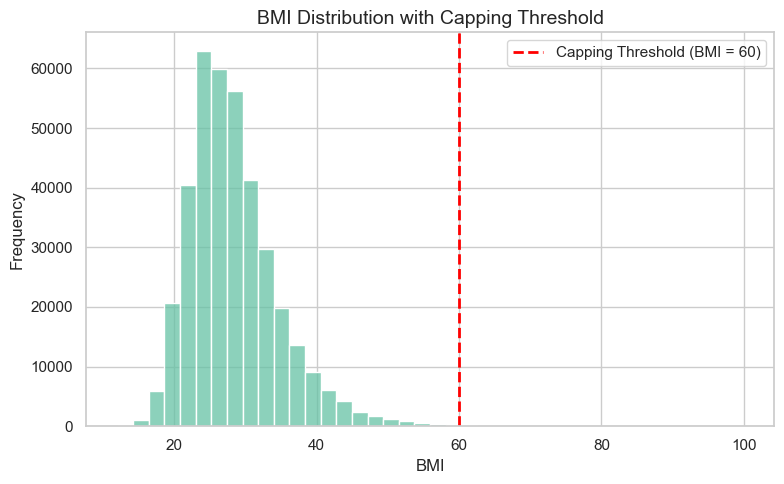

In [21]:
# Visualize BMI distribution with a histogram and indicate the capping threshold at BMI = 60
plt.figure(figsize=(8, 5))

# Histogram
sns.histplot(
    data=ml_df,
    x="BMI",
    bins=40
)

# Capping threshold
plt.axvline(
    x=60,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Capping Threshold (BMI = 60)"
)

plt.title("BMI Distribution with Capping Threshold", fontsize=14)
plt.xlabel("BMI", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

 **Observation** 

The `BMI` variable in the BRFSS 2023 dataset is stored as an integer
representing Body Mass Index multiplied by 100. Following rescaling by dividing
all values by 100, the variable now represents true BMI in standard units
(kg/m²). The rescaled values range from a minimum of **12.02** to a maximum of
**99.84**, with a mean of **28.48** consistent with the known average BMI of
the US adult population and aligning with published BRFSS summary statistics.

The maximum value of 99.84 warrants attention. A BMI exceeding 60 is considered
physiologically implausible for reliable self-reported height and weight data.
The BRFSS codebook assigns extreme calculated BMI values near the upper limit
when reported height and weight measurements are inconsistent. These extreme
outliers will be identified and capped during the feature engineering phase to
prevent them from distorting model training.

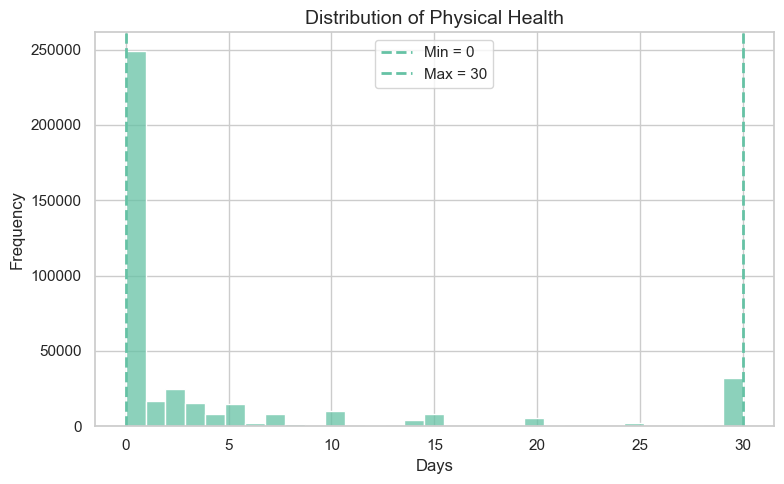

In [22]:
# Summary statistics
min_val = ml_df["Physical_Health"].min()
max_val = ml_df["Physical_Health"].max()

# Plot
plt.figure(figsize=(8, 5))

sns.histplot(
    data=ml_df,
    x="Physical_Health",
    bins=31
)

# Minimum and maximum reference lines
plt.axvline(
    min_val,
    linestyle="--",
    linewidth=2,
    label=f"Min = {min_val:.0f}"
)

plt.axvline(
    max_val,
    linestyle="--",
    linewidth=2,
    label=f"Max = {max_val:.0f}"
)

plt.title("Distribution of Physical Health", fontsize=14)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

`Physical_Health` falls entirely within the expected valid range of **0 to 30 days**
following the recoding of the `88` special case to `0` ,
confirming no further treatment is required for this variable.

In [23]:
# Summary of data cleaning
cleaning_summary = pd.DataFrame({
    "missing_count": ml_df[features + [target]].isna().sum(),
    "missing_percent": (ml_df[features + [target]].isna().mean() * 100).round(2),
    "unique_values": ml_df[features + [target]].nunique(dropna=True),
})

cleaning_summary.sort_values("missing_percent", ascending=False)


,missing_count,missing_percent,unique_values
Income_Level,83361,19.92,11
High_Cholesterol,53416,12.76,2
BMI,38910,9.30,4033
Ever_Smoked,21776,5.20,2
Physical_Health,10152,2.43,31
Heart_Disease,4077,0.97,2
Education_Level,2146,0.51,6
Hypertension,1646,0.39,2
Kidney_Disease,1522,0.36,2
Physical_Activity,1159,0.28,2


After cleaning special BRFSS response codes, the highest missingness appears in `Income_Level` (19.92%), `High_Cholesterol` (12.76%), `BMI` (9.30%), and `Ever_Smoked` (5.20%). These variables will not be dropped because removing all rows with missing predictor values would discard a large amount of useful survey data. Instead, missing predictor values will be handled with imputation after the train-test split to avoid data leakage.

In [24]:
# Map categorical variables to binary values for modeling to ensure consistency and interpretability.
ml_df["Hypertension"] = ml_df["Hypertension"].map({
    1: 0,  # No hypertension
    2: 1   # Hypertension
})

ml_df["High_Cholesterol"] = ml_df["High_Cholesterol"].map({
    1: 0,  # No high cholesterol
    2: 1   # High cholesterol
})

ml_df["Kidney_Disease"] = ml_df["Kidney_Disease"].map({
    1: 1,  # Kidney disease
    2: 0   # No kidney disease
})

ml_df["Heart_Disease"] = ml_df["Heart_Disease"].map({
    1: 1,  # Heart disease
    2: 0   # No heart disease
})

ml_df["Ever_Smoked"] = ml_df["Ever_Smoked"].map({
    1: 1,  # Smoked 100 cigarettes
    2: 0   # Did not smoke 100 cigarettes
})

ml_df["Physical_Activity"] = ml_df["Physical_Activity"].map({
    1: 1,  # Physically active
    2: 0   # Not physically active
})

### Cleaning Notes

Missing values remain in predictor columns by design. They are handled inside the preprocessing pipeline after the train/test split, which prevents information from the test set from influencing imputation values learned from training data.

## 8. Exploratory Data Analysis
Exploratory Data Analysis (EDA) is conducted on the cleaned dataset 
to develop a thorough understanding of the data before modelling.
EDA serves as a critical bridge between data preparation and feature
engineering, providing insights that directly inform preprocessing decisions,
feature selection, and model strategy.

The objectives of this section are to:

- Examine the statistical properties and distributions of all 14 predictor
  variables.
- Investigate the relationship between each predictor and the binary diabetes
  outcome.
- Assess the degree and pattern of missing values across the dataset.
- Identify potential multicollinearity between features.



All analysis in this section is conducted on `ml_df` the cleaned but
untransformed dataset to ensure that EDA reflects the true characteristics
of the data prior to any scaling, imputation, or engineering transformations.
### 8.1. Univariate analysis
Univariate analysis examines each variable independently to understand its individual characteristics before exploring relationships with other variables. This stage provides insights into the distribution, central tendency, variability, and frequency of each predictor, helping identify unusual patterns, potential outliers, and data quality issues that may influence subsequent analyses and model development.

### 8.1.1 Summary Statistics

Summary statistics provide a quantitative overview of the central tendency, variability, and range of the continuous variables included in the study. Measures such as the mean, median, standard deviation, minimum, maximum, and quartiles help characterize the distribution of each variable and identify potential skewness or extreme observations.

The statistics presented in this section are computed using the cleaned dataset (`ml_df`), after BRFSS special response codes (e.g., "Don't know", "Refused", and "Not applicable") have been appropriately recoded and missing values handled during the data preparation stage. These summaries establish a baseline understanding of the continuous predictors before more detailed exploratory analyses are performed.



In [25]:
# Summary statistics for all features and target
print("=== Summary Statistics ===\n")

summary = ml_df.describe().T
summary["missing"] = ml_df.isnull().sum()
summary["missing_%"] = (ml_df.isnull().mean() * 100).round(2)

# Round for readability
summary = summary.round(3)

print(summary[[
    "count", "mean", "std", "min",
    "25%", "50%", "75%", "max",
    "missing", "missing_%"
]].to_string())

=== Summary Statistics ===

                      count    mean     std    min    25%    50%    75%    max  missing  missing_%
BMI                379582.0  28.404   6.498  12.02  24.03  27.37  31.57  99.84    38910       9.30
Age                418492.0  55.318  17.963  18.00  41.00  58.00  71.00  80.00        0       0.00
Sex                418492.0   1.526   0.499   1.00   1.00   2.00   2.00   2.00        0       0.00
Race_Ethnicity     418492.0   1.756   1.499   1.00   1.00   1.00   2.00   6.00        0       0.00
General_Health     417336.0   2.604   1.048   1.00   2.00   3.00   3.00   5.00     1156       0.28
Physical_Health    408340.0   4.430   8.780   0.00   0.00   0.00   4.00  30.00    10152       2.43
Ever_Smoked        396716.0   0.386   0.487   0.00   0.00   0.00   1.00   1.00    21776       5.20
Physical_Activity  417333.0   0.754   0.430   0.00   1.00   1.00   1.00   1.00     1159       0.28
Education_Level    416346.0   5.048   1.008   1.00   4.00   5.00   6.00   6.00   

Observations
- Missing data are concentrated in Income_Level, High_Cholesterol, BMI, and Ever_Smoked, supporting the use of imputation during preprocessing.
- BMI contains extreme values (up to 99.84), motivating the decision to cap values above 60 during feature engineering.
- Physical health is highly right-skewed, with most respondents reporting 0 unhealthy days.
- The target variable is imbalanced (approximately 14% positive cases), making class imbalance handling an important aspect of model development.

### 8.1.1 Target Distribution

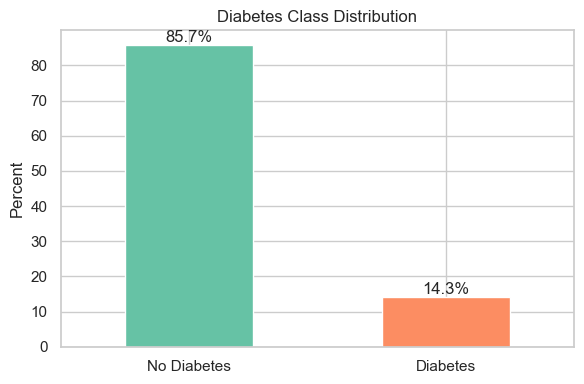

In [26]:
# Visualize the distribution of the target variable
# Create a bar plot to show the distribution of diabetes and no diabetes in the dataset
target_dist = ml_df[target].value_counts(normalize=True).sort_index() * 100

ax = target_dist.plot(kind="bar", figsize=(6, 4), color=["#66c2a5", "#fc8d62"])
ax.set_xticklabels(["No Diabetes", "Diabetes"], rotation=0)
ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.set_title("Diabetes Class Distribution")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()


**Observation** 

The constructed binary target variable exhibits a class imbalance,
with 85.7% negative cases and 14.3% positive cases. This is consistent with
the known prevalence of Type 2 diabetes in the US adult population and confirms
the epidemiological validity of the dataset.

While moderate rather than severe, this imbalance is sufficient to bias standard
classification algorithms toward the majority class producing models that
achieve high accuracy by predominantly predicting no diabetes while failing to
identify the patients the system is designed to flag. A naive majority-class
classifier would already achieve **86% accuracy without any learning**, making
accuracy alone a misleading success criterion.

Given the clinical context, a **false negative**  diabetic patient classified
as healthy  carries significantly greater harm than a false positive. For this
reason, **Recall on the positive class** is adopted as the primary evaluation
metric throughout this project.

### 8.1.2 Correlation heatmap of the target variable and the features

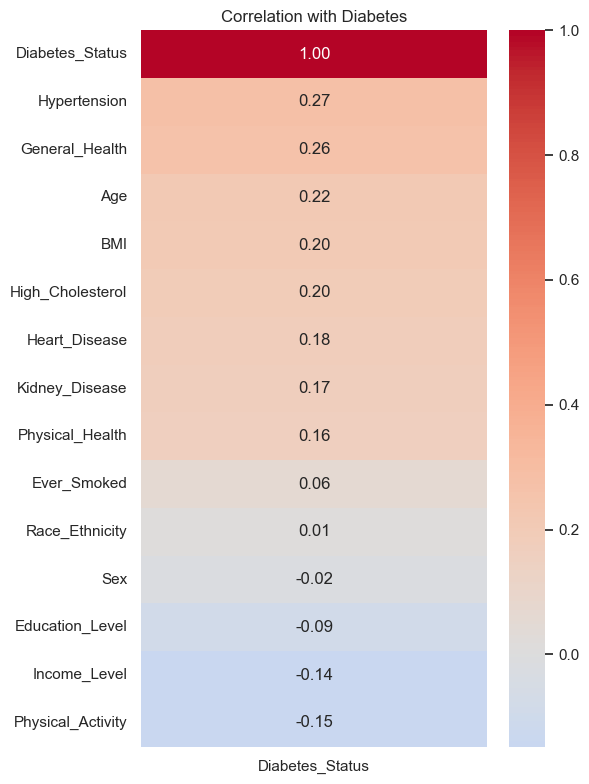

In [27]:
# Visualize correlations of features with diabetes
numeric_for_corr = ml_df.copy()
corr_target = (
    numeric_for_corr[features + [target]]
    .corr(numeric_only=True)[[target]]
    .sort_values(target, ascending=False)
)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation with Diabetes")
plt.tight_layout()
plt.show()


**Observation**

Hypertension shows the strongest positive correlation with diabetes (r = 0.27), followed by poor general health (r = 0.26), age (r = 0.22), BMI (r = 0.20) and high cholesterol (r = 0.20), and . Heart and kidney disease also show modest positive associations. Physical activity has a weak positive correlation (r = 0.16), likely reflecting behavioral changes after diagnosis rather than a causal effect. Race shows nearly no linear relationship, while income and education are negatively correlated with diabetes. Smoking, sex, and physical health days show very weak associations.

### 8.2. Bivariate analysis
Bivariate analysis examines the relationship between two variables to determine how individual predictor variables are associated with the target variable (`diabetes`). Unlike univariate analysis, which considers variables independently, bivariate analysis evaluates whether differences in a predictor correspond to differences in diabetes prevalence.

In this study, each predictor is analysed against the diabetes outcome to identify characteristics that distinguish respondents with and without Type 2 diabetes. For categorical and ordinal variables, diabetes prevalence is calculated for each response category and visualised using bar charts. Continuous variables are analysed using appropriate comparative visualisations.

These analyses provide an intuitive understanding of the strength and direction of each predictor's association with diabetes and offer an initial indication of variables that are likely to contribute to predictive model performance.

## 8.2.1 Binary Clinical Risk Factors

Binary clinical risk factors represent the presence or absence of chronic health conditions that are well‑established predictors of Type 2 diabetes. This analysis examines the prevalence of diabetes among respondents with and without each condition to assess the strength of their association with the target variable.

The variables considered include:

- Hypertension  
- High cholesterol  
- Kidney disease   

For each factor, the percentage of respondents diagnosed with diabetes is calculated and visualized using bar charts. Comparing diabetes prevalence across these binary groups provides an intuitive assessment of which clinical conditions are most strongly associated with diabetes risk within the BRFSS 2023 population.
#### 8.2.1.1. Diabetes rate by Hypertension

In [28]:
# Diabetes rate by hypertension
# Calculate diabetes rate by hypertension status
hypertension_rate = (
    ml_df.groupby("Hypertension")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

hypertension_rate["Hypertension"] = hypertension_rate["Hypertension"].map({
    0: "No Hypertension",
    1: "Hypertension"
})

hypertension_rate

,Hypertension,Diabetes_Status
0,No Hypertension,6.351184
1,Hypertension,25.933252


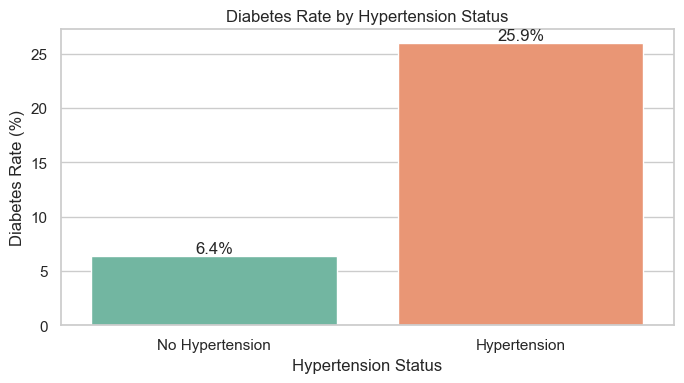

In [29]:
# Visualize diabetes rate by hypertension status
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=hypertension_rate,
    x="Hypertension",
    y="Diabetes_Status",
    palette=["#66c2a5", "#fc8d62"]
)

plt.xlabel("Hypertension Status")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Hypertension Status")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows a strong relationship between hypertension and diabetes. Among respondents without hypertension, the diabetes rate is only 6.4%, while among respondents with hypertension, it rises to 25.9%.
This means people with hypertension have about 4 times higher diabetes prevalence than those without hypertension.

### 8.2.1.2 Diabetes rate by cholesterol levels

In [30]:
# Diabetes rate by cholesterol
# Calculate diabetes rate by cholesterol status
cholesterol_rate = (
    ml_df.groupby("High_Cholesterol")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

cholesterol_rate["High_Cholesterol"] = cholesterol_rate["High_Cholesterol"].map({
    0: "No High Cholesterol",
    1: "High Cholesterol"
})

cholesterol_rate

,High_Cholesterol,Diabetes_Status
0,No High Cholesterol,9.468580
1,High Cholesterol,23.961015


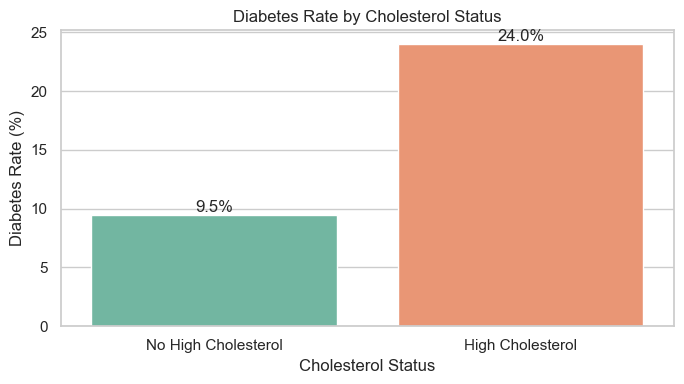

In [31]:
# Visualize diabetes rate by cholesterol status
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=cholesterol_rate,
    x="High_Cholesterol",
    y="Diabetes_Status",
    palette=["#66c2a5", "#fc8d62"]
)

plt.xlabel("Cholesterol Status")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Cholesterol Status")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows that diabetes is much more common among respondents with high cholesterol. The diabetes rate is 9.5% for respondents without high cholesterol, compared with 24.0% for respondents with high cholesterol.

### 8.2.1.3. Diabetes rate by kidney disease

In [32]:
# Diabetes rate by kidney disease
# Create a mapping for kidney disease categories
kidney_map = {
    0: "No Kidney Disease",
    1: "Kidney Disease"
}

ml_df["Kidney_Disease"] = ml_df["Kidney_Disease"].map(kidney_map)

kidney_rate = (
    ml_df.groupby("Kidney_Disease")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

kidney_rate

,Kidney_Disease,Diabetes_Status
0,Kidney Disease,41.500403
1,No Kidney Disease,12.856251


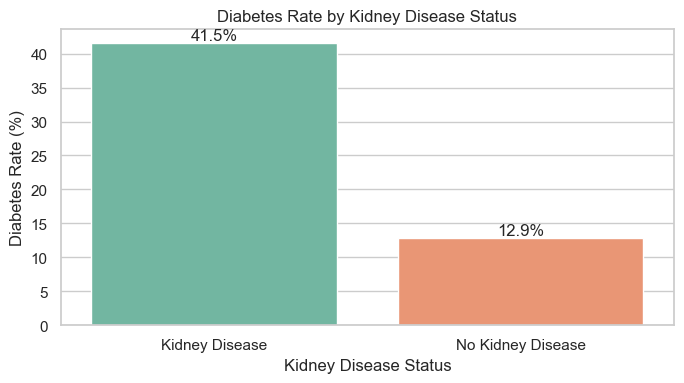

In [33]:
# Visualize diabetes rate by kidney disease
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=kidney_rate,
    x="Kidney_Disease",
    y="Diabetes_Status",
    palette=["#66c2a5", "#fc8d62"]
)

plt.xlabel("Kidney Disease Status")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Kidney Disease Status")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows a very strong association between kidney disease and diabetes. Respondents with kidney disease have a diabetes rate of 41.5%, compared with 12.9% among respondents without kidney disease.

## 8.2.2. Lifestyle Risk Factors

Lifestyle behaviors play a significant role in the development and prevention of Type 2 diabetes. Behaviors such as cigarette smoking and physical inactivity contribute to insulin resistance, obesity, and cardiovascular complications, increasing an individual's likelihood of developing diabetes.

This analysis examines the prevalence of diabetes among respondents based on their smoking history and physical activity status. Comparing diabetes prevalence across these behavioral groups provides insight into the association between modifiable lifestyle factors and diabetes risk within the BRFSS 2023 population.

### 8.2.2.1 Diabetes rate by BMI Category

In [34]:
# Diabetes rate by BMI category
# Create BMI categories for analysis
ml_df["BMI_Category"] = pd.cut(
    ml_df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

bmi_rate = (
    ml_df.groupby("BMI_Category")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

bmi_rate

,BMI_Category,Diabetes_Status
0,Underweight,5.434783
1,Normal,6.992976
2,Overweight,12.867680
3,Obese,23.341523


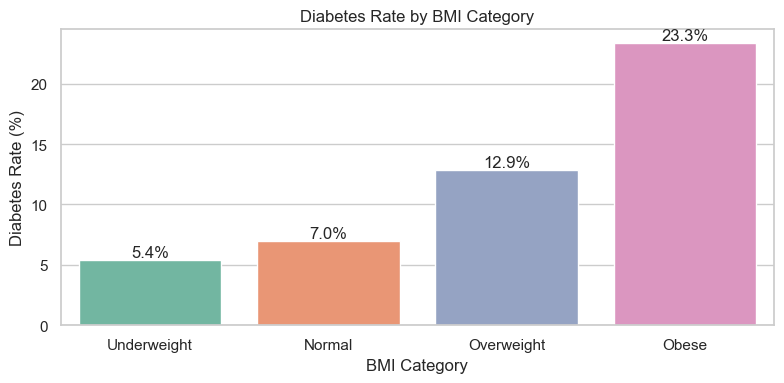

In [35]:
# Visualize diabetes rate by BMI category
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=bmi_rate,
    x="BMI_Category",
    y="Diabetes_Status",
    palette="Set2"
)

plt.xlabel("BMI Category")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by BMI Category")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The chart shows a clear upward trend between BMI category and diabetes rate. Diabetes prevalence increases from 5.4% among underweight respondents to 23.3% among respondents with obesity.

### 8.2.2.2 Diabetes rate by general health

In [36]:
# Diabetes rate by general health
# Create a mapping for general health categories
health_map = {
    1: "Excellent",
    2: "Very Good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

ml_df["General_Health"] = ml_df["General_Health"].map(health_map)

health_rate = (
    ml_df.groupby("General_Health")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

health_order = ["Excellent", "Very Good", "Good", "Fair", "Poor"]
health_rate["General_Health"] = pd.Categorical(
    health_rate["General_Health"],
    categories=health_order,
    ordered=True
)

health_rate = health_rate.sort_values("General_Health")
health_rate

,General_Health,Diabetes_Status
0,Excellent,3.178429
4,Very Good,7.544169
2,Good,16.644056
1,Fair,28.716291
3,Poor,37.092538


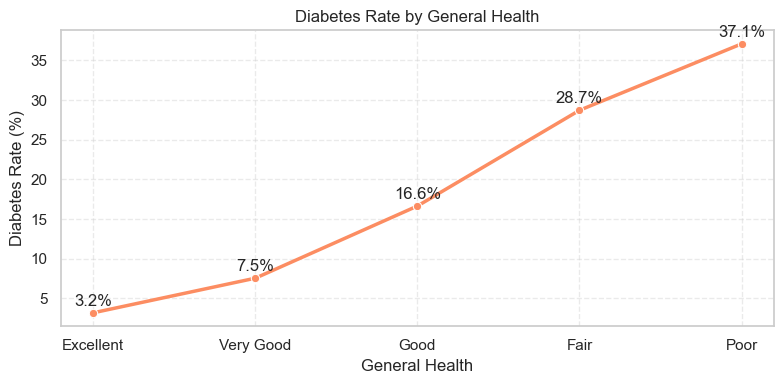

In [40]:
# Visualize diabetes rate by general health as a line graph

plt.figure(figsize=(8, 4))

ax = sns.lineplot(
    data=health_rate,
    x="General_Health",
    y="Diabetes_Status",
    marker="o",
    linewidth=2.5,
    color= "#fc8d62"
)

plt.xlabel("General Health")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by General Health")
plt.grid(True, linestyle="--", alpha=0.4)

for x, y in zip(health_rate["General_Health"], health_rate["Diabetes_Status"]):
    plt.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

- Diabetes prevalence increased from 3.2% among participants reporting Excellent health to 37.1% among those reporting Poor health.
Participants reporting Poor health had the highest prevalence of diabetes.
- The steady upward trend indicates a strong association between poorer general health and Type 2 Diabetes.

## 8.2.3 Demographic Factors

Demographic characteristics influence an individual's susceptibility to Type 2
diabetes through a combination of biological, socioeconomic, and environmental
factors. This section examines how diabetes prevalence varies across different
population groups, including age, sex, race/ethnicity, educational attainment,
and household income.

Unlike binary predictors, these variables contain multiple categories. Diabetes
prevalence is therefore calculated for each category and visualised using line
or bar charts to reveal trends, gradients, and disparities across the BRFSS
2023 population.

### 8.2.3.1 Diabetes rate by age group
Age is one of the strongest non-modifiable risk factors for Type 2 diabetes.
The prevalence of diabetes is expected to increase with advancing age due to
the cumulative effects of insulin resistance, metabolic changes, and prolonged
exposure to lifestyle and environmental risk factors.

This analysis computes the percentage of respondents with diabetes for each age
group to examine how disease prevalence changes across the adult lifespan.

In [38]:
# Diabetes rate by age group
# Create age groups for analysis
ml_df["Age_Group"] = pd.cut(
    ml_df["Age"],
    bins=[17, 30, 40, 50, 60, 70, 80],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "71-80"]
)
# Calculate diabetes rate by age group
age_rate = (
    ml_df.groupby("Age_Group")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
)

age_rate

,Age_Group,Diabetes_Status
0,18-30,1.483943
1,31-40,3.929647
2,41-50,9.249071
3,51-60,16.093088
4,61-70,20.545129
5,71-80,21.965638


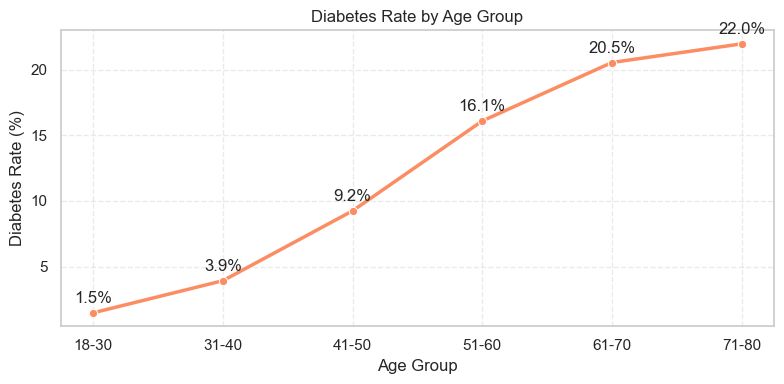

In [39]:
# Visualize diabetes rate by age group as a line graph

plt.figure(figsize=(8, 4))

ax = sns.lineplot(
    data=age_rate,
    x="Age_Group",
    y="Diabetes_Status",
    marker="o",
    linewidth=2.5,
    color="#fc8d62"
)

plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Age Group")
plt.grid(True, linestyle="--", alpha=0.4)

for x, y in zip(age_rate["Age_Group"], age_rate["Diabetes_Status"]):
    plt.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()                                                                                          

Diabetes prevalence by age group. 
- The prevalence of Type 2 Diabetes increases progressively with age, rising from 1.5% among adults aged 18–30 years to 22.0% among those aged 71–80 years. This trend highlights age as a significant risk factor for type 2 diabetes.
- Clinical evidence: The risk of Type 2 Diabetes generally increases with age due to reduced insulin sensitivity, progressive pancreatic β-cell dysfunction, and the accumulation of metabolic risk factors over time.

### 8.2.3.2 Diabetes rate by Sex
Sex is an important demographic factor that may influence the risk of developing Type 2 diabetes through differences in physiology, body composition, hormonal regulation, and health‑related behaviors. Examining diabetes prevalence by sex provides insight into whether the burden of disease differs between males and females within the BRFSS 2023 population.

This analysis compares the proportion of respondents with diabetes across the two sex categories to assess the strength and direction of their association with Type 2 diabetes.

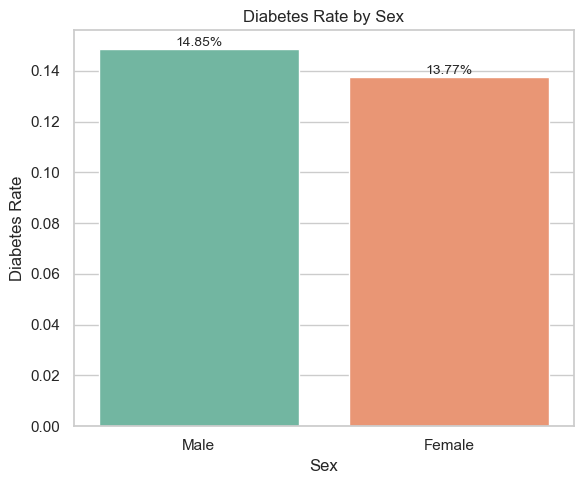

In [41]:
sex_rate = (
    ml_df.groupby("Sex")["Diabetes_Status"]
      .mean()
      .reset_index()
)

sex_rate["Sex"] = sex_rate["Sex"].map({
    1: "Male",
    2: "Female"
})

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=sex_rate,
    x="Sex",
    y="Diabetes_Status",
    palette="Set2"
)

plt.title("Diabetes Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Diabetes Rate")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2%}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Interpretation: 
- The diabetes rate was 14.85% for males and 13.77% for females.
Males had a slightly higher diabetes rate than females.
- The difference was small (1.1 percentage points), indicating that sex has a weak association with diabetes in this dataset.

### 8.2.3.3 Diabetes rate by ethnicity/ rate
Race and ethnicity are important social determinants of health that may influence the prevalence of Type 2 diabetes through differences in genetic predisposition, socioeconomic conditions, healthcare access, and lifestyle factors. Examining diabetes prevalence across racial and ethnic groups helps identify disparities in disease burden and provides insight into population groups that may benefit from targeted prevention and intervention strategies.

In [42]:
# Diabetes rate by ethnicity / race
# Create a mapping for race/ethnicity categories
race_map = {
    1: "White",
    2: "Black",
    3: "American Indian / Alaska Native",
    4: "Asian",
    5: "Other race",
    6: "Multiracial"
}

ml_df["Ethnicity"] = ml_df["Race_Ethnicity"].map(race_map)

ethnicity_rate = (
    ml_df.groupby("Ethnicity")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("Diabetes_Status", ascending=False)
)

ethnicity_rate

,Ethnicity,Diabetes_Status
2,Black,21.190975
1,Asian,21.106743
3,Multiracial,14.902625
4,Other race,14.219035
5,White,13.526705
0,American Indian / Alaska Native,11.208829


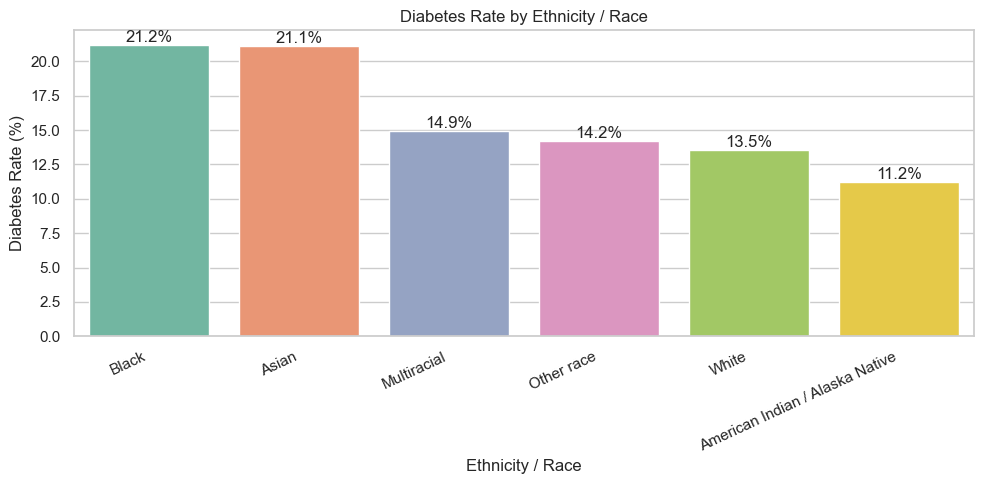

In [43]:
# Visualize diabetes rate by ethnicity / race
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=ethnicity_rate,
    x="Ethnicity",
    y="Diabetes_Status",
    palette="Set2"
)

plt.xlabel("Ethnicity / Race")
plt.ylabel("Diabetes Rate (%)")
plt.title("Diabetes Rate by Ethnicity / Race")
plt.xticks(rotation=25, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


The chart shows differences in diabetes prevalence across ethnicity/race groups. The highest diabetes rates appear among Black respondents (21.2%) and Asian respondents (21.1%), followed by Multiracial respondents (14.9%) and Other race respondents (14.2%).

### 8.2.3.4 Diabetes Prevalence by Education Level

Education is a key social determinant of health that influences health literacy, employment opportunities, income, and access to healthcare. Individuals with higher educational attainment are generally more likely to engage in preventive health behaviors and adopt healthier lifestyles, which may reduce the risk of developing Type 2 diabetes.

In [44]:
education_diabetes = (
    ml_df.groupby("Education_Level")["Diabetes_Status"]
    .mean()
    .mul(100)  # Convert to percentage
    .reset_index(name="Diabetes_Prevalence")
)

education_diabetes

education_labels = {
    1: "Never\nAttended",
    2: "Elementary",
    3: "Some High\nSchool",
    4: "High School\nGraduate",
    5: "Some College",
    6: "College\nGraduate"
}

education_diabetes["Education"] = (
    education_diabetes["Education_Level"].map(education_labels)
)

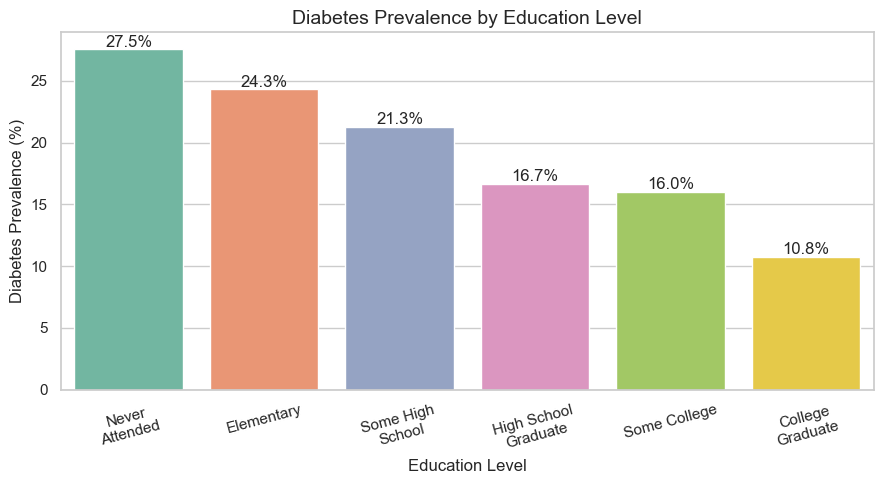

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=education_diabetes,
    x="Education",
    y="Diabetes_Prevalence",
    palette="Set2"
)

plt.title("Diabetes Prevalence by Education Level", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Diabetes Prevalence (%)", fontsize=12)
plt.xticks(rotation=15)

for i, value in enumerate(education_diabetes["Diabetes_Prevalence"]):
    plt.text(i, value + 0.2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

 **Observations**

Diabetes prevalence generally decreases as educational attainment increases, indicating an inverse relationship between education and Type 2 diabetes risk. Respondents with lower levels of education exhibit the highest prevalence of diabetes, while college graduates show the lowest prevalence. This pattern suggests that higher educational attainment may contribute to improved health literacy, healthier lifestyle choices, better employment opportunities, and greater access to healthcare services. The findings highlight education as an important socioeconomic factor associated with diabetes risk and support its inclusion as a predictor in the machine learning models.

### 8.2.3.5 Diabetes Prevalence by Income Level

Income is an important socioeconomic determinant of health that influences access to nutritious food, healthcare services, health insurance, and opportunities for maintaining healthy lifestyles. Individuals with lower household incomes often experience greater exposure to risk factors associated with chronic diseases, including Type 2 diabetes.

This analysis examines the prevalence of diabetes across different household income categories to identify potential socioeconomic disparities in diabetes burden within the BRFSS 2023 population.

In [48]:
# Calculate diabetes prevalence by income level
income_diabetes = (
    ml_df.groupby("Income_Level")["Diabetes_Status"]
    .mean()
    .mul(100)
    .reset_index(name="Diabetes_Prevalence")
)

# BRFSS income labels
income_labels = {
    1: "< $10,000",
    2: "$10k–15k",
    3: "$15k–20k",
    4: "$20k–25k",
    5: "$25k–35k",
    6: "$35k–50k",
    7: "$50k–75k",
    8: "$75k–100k",
    9: "$100k–150k",
    10: "$150k–200k",
    11: "≥ $200k"
}

# Map labels
income_diabetes["Income"] = (
    income_diabetes["Income_Level"].map(income_labels)
)


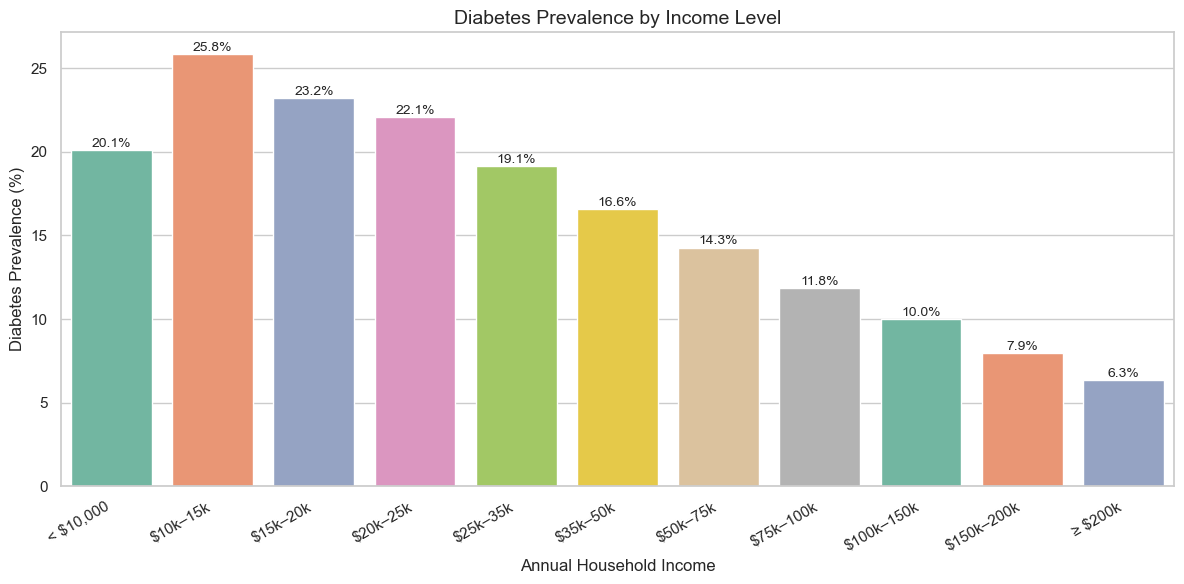

In [49]:
# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=income_diabetes,
    x="Income",
    y="Diabetes_Prevalence",
    palette="Set2"
)

plt.title("Diabetes Prevalence by Income Level", fontsize=14)
plt.xlabel("Annual Household Income", fontsize=12)
plt.ylabel("Diabetes Prevalence (%)", fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha="right")

# Add percentage labels
for i, value in enumerate(income_diabetes["Diabetes_Prevalence"]):
    plt.text(i, value + 0.2, f"{value:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

  **Observations**

The relationship between household income and diabetes prevalence shows a clear socioeconomic gradient. Diabetes prevalence is highest among respondents earning ***$10,000–$15,000*** annually ***(25.8%)***, followed by those earning less than ***$10,000***  ***(20.1%)***. Beyond these lowest income groups, the prevalence declines progressively as household income increases, with the highest-income respondents exhibiting the lowest diabetes rates. This pattern suggests that lower socioeconomic status is associated with a greater burden of Type 2 diabetes, potentially reflecting disparities in healthcare access, nutrition, education, and opportunities for maintaining healthy lifestyles. Overall, household income appears to be an important predictor of diabetes risk within the BRFSS population.

### 8.3. Multivariate analysis
Multivariate analysis examines the relationships among multiple variables simultaneously to identify underlying patterns and dependencies within the dataset. Unlike bivariate analysis, which considers one predictor at a time, multivariate analysis evaluates how variables relate to one another as a whole, providing a broader understanding of the dataset's structure.

In this study, multivariate analysis focuses on the correlation between predictor variables and the target variable (`Diabetes_Status`), as well as the relationships among predictors themselves. A correlation heatmap is used to visualise the strength and direction of these associations and to identify potential multicollinearity that could influence model development.

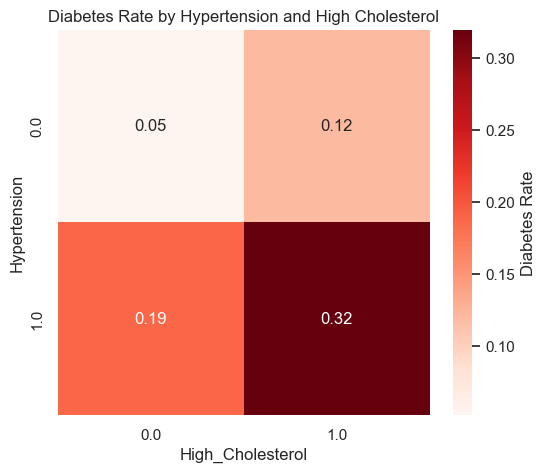

In [50]:
# Diabetes rate by hypertension and high cholesterol
pivot = pd.crosstab(
    ml_df["Hypertension"],
    ml_df["High_Cholesterol"],
    values=ml_df["Diabetes_Status"],
    aggfunc="mean"
)

plt.figure(figsize=(6,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    cbar_kws={"label": "Diabetes Rate"}
)

plt.title("Diabetes Rate by Hypertension and High Cholesterol")
plt.show()

Interpretation of the Heatmap
- The lowest diabetes rate (5%) was observed among individuals with neither hypertension nor high cholesterol.
Participants with high cholesterol only had a higher diabetes rate (12%) than those with neither condition.
- Individuals with hypertension only had an even higher diabetes rate (19%), indicating hypertension is more strongly associated with diabetes than high cholesterol alone.
- The highest diabetes rate (32%) was observed among participants with both hypertension and high cholesterol.
- Overall, the heatmap suggests that the presence of both hypertension and high cholesterol substantially increases the likelihood of diabetes, highlighting their combined effect as important risk factors for Type 2 diabetes.

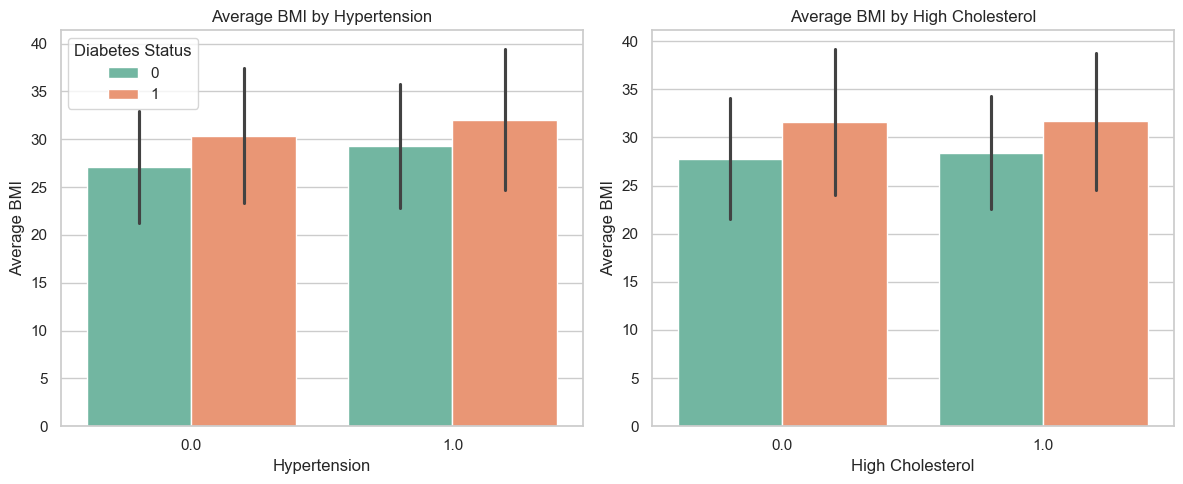

In [51]:
# Visualize average BMI by hypertension and high cholesterol, separated by diabetes status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hypertension
sns.barplot(
    data=ml_df,
    x="Hypertension",
    y="BMI",
    hue="Diabetes_Status",
    errorbar="sd",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Average BMI by Hypertension")
axes[0].set_xlabel("Hypertension")
axes[0].set_ylabel("Average BMI")

# High Cholesterol
sns.barplot(
    data=ml_df,
    x="High_Cholesterol",
    y="BMI",
    hue="Diabetes_Status",
    errorbar="sd",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Average BMI by High Cholesterol")
axes[1].set_xlabel("High Cholesterol")
axes[1].set_ylabel("Average BMI")

# Show only one legend
axes[1].legend_.remove()
axes[0].legend(title="Diabetes Status")

plt.tight_layout()
plt.show()

Interpretation of Grouped Bar Plots
- Participants with diabetes consistently had a higher average BMI than those without diabetes across all groups.
Individuals with hypertension had a slightly higher average BMI than those without hypertension, regardless of diabetes status.
- Similarly, participants with high cholesterol showed a marginally higher average BMI than those without high cholesterol.
- The highest average BMI was observed among individuals with both diabetes and hypertension, followed closely by those with diabetes and high cholesterol.
- The error bars indicate variability in BMI within each group, but the overall trend of higher BMI among participants with diabetes remains consistent.

Key Insight: 
- The plots suggest that higher BMI is associated with diabetes and is more pronounced among individuals with hypertension or high cholesterol, supporting these factors as important risk indicators for Type 2 diabetes.

### EDA Insights

The exploratory analysis typically shows diabetes prevalence rising with age, BMI, poorer general health, hypertension, high cholesterol and kidney disease. These patterns support the modeling strategy: combine clinical risk factors, demographics, socioeconomic proxies, and health behaviors into a risk-screening model rather than relying on a single predictor.


## 9. Modeling Preparation


### 9.1. Feature Engineering

Feature engineering transforms the cleaned dataset into a form that maximises
the predictive power of machine learning models. While the data preparation
phase addressed structural issues invalid codes, target construction, and
data quality.
Feature engineering applies mathematical and statistical
transformations that directly influence how models learn from the data.
The following steps are performed in this section:

- **Missingness indicator variables** are added for predictors with relatively high missingness.
- **Train / Test Split** — Partitioning the dataset into training and test
  sets before any fitting operations to prevent data leakage.
- **Missing Value Imputation** — Median imputation fitted on the training
  set only and applied to both sets.
- **Feature Scaling** — StandardScaler applied to continuous variables
  to normalise their range for distance-based and gradient-based algorithms.
- **Class Imbalance Handling** — applied to the training set only
  to address the  class imbalance.
- **Preprocessing Pipeline** — All transformations encapsulated in a
  scikit-learn `Pipeline` object for reproducibility and safe deployment.

All transformations are fitted exclusively on the training set and applied
to the test set using the fitted parameters, ensuring the test set remains
a true holdout and no information leaks into model evaluation.

### 9.1.1. Outlier Treatment
`BMI` was identified as containing **780 extreme values**
above the clinical ceiling of **60.00**, arising from inconsistent
self-reported height and weight measurements. These values are capped using
**Winsorization**  values above 60.00 are replaced with 60.00 rather than
removed, preserving all 429,086 records while limiting the influence of
implausible measurements on model training.

No other variables require outlier treatment. All binary and ordinal features
have fixed valid ranges enforced during BRFSS code recoding,
and `Physical_Health` was confirmed to fall within its valid 0–30 range.

In [52]:
# Cap clinical ceiling to 60
BMI_CEILING = 60.0

before_max = ml_df["BMI"].max()
ml_df["BMI"] = ml_df["BMI"].clip(upper=BMI_CEILING)
after_max  = ml_df["BMI"].max()


print(f"   Before max : {before_max:.2f}")
print(f"   After max  : {after_max:.2f}")
print(f"   Records retained : {len(ml_df):,}")

   Before max : 99.84
   After max  : 60.00
   Records retained : 418,492


Winsorization was successfully applied to `BMI`, capping all values above
**60.00** at the clinical ceiling. The maximum BMI value reduced from **99.84**
to **60.00**, while the mean and distribution of the remaining values are
preserved. All **418,492 records** are retained no observations were removed.

### 9.1.1. Missingness indicator
Missingness indicator variables were added for predictors with relatively high missingness. This allows the model to retain information about whether a respondent skipped or had missing information for variables such as income, cholesterol, BMI, and smoking. The original missing values are still imputed later, but the indicator columns help the model learn whether missingness itself is associated with diabetes risk.

In [53]:
# Columns where missingness is high enough to track
missing_indicator_features = [
    "Income_Level",
    "High_Cholesterol",
    "BMI",
    "Ever_Smoked"
]

missing_indicator_features

['Income_Level', 'High_Cholesterol', 'BMI', 'Ever_Smoked']

In [54]:
# Create missingness indicator columns
model_df = ml_df.copy()

for col in missing_indicator_features:
    model_df[col + "_missing"] = model_df[col].isna().astype(int)

model_df.head()

,BMI,Age,Sex,Race_Ethnicity,General_Health,Physical_Health,Ever_Smoked,Physical_Activity,Education_Level,Income_Level,Hypertension,High_Cholesterol,Kidney_Disease,Heart_Disease,Diabetes_Status,BMI_Category,Age_Group,Ethnicity,Income_Level_missing,High_Cholesterol_missing,BMI_missing,Ever_Smoked_missing
0,30.47,80.0,2.0,1.0,Very Good,0.0,0.0,0.0,5.0,NaN,1.0,0.0,No Kidney Disease,0.0,1,Obese,71-80,White,1,0,0,0
1,28.56,80.0,2.0,1.0,Very Good,0.0,0.0,1.0,5.0,NaN,1.0,1.0,No Kidney Disease,0.0,0,Overweight,71-80,White,1,0,0,0
2,22.31,80.0,2.0,2.0,Fair,6.0,1.0,1.0,4.0,2.0,1.0,1.0,No Kidney Disease,0.0,0,Normal,71-80,Black,0,0,0,0
3,27.44,78.0,2.0,1.0,Very Good,2.0,0.0,1.0,5.0,NaN,0.0,0.0,No Kidney Disease,0.0,0,Overweight,71-80,White,1,0,0,0
4,25.85,76.0,2.0,1.0,Fair,0.0,0.0,1.0,5.0,7.0,1.0,0.0,No Kidney Disease,0.0,1,Overweight,71-80,White,0,0,0,0


In [55]:
# Original features plus missingness indicators
indicator_features = [
    col + "_missing" for col in missing_indicator_features
]

model_features = features + indicator_features

model_features

['BMI',
 'Age',
 'Sex',
 'Race_Ethnicity',
 'General_Health',
 'Physical_Health',
 'Ever_Smoked',
 'Physical_Activity',
 'Education_Level',
 'Income_Level',
 'Hypertension',
 'High_Cholesterol',
 'Kidney_Disease',
 'Heart_Disease',
 'Income_Level_missing',
 'High_Cholesterol_missing',
 'BMI_missing',
 'Ever_Smoked_missing']

In [56]:
# Define predictors and target
X = model_df[model_features]
y = model_df["Diabetes_Status"]

print(X.shape)
print(y.shape)

(418492, 18)
(418492,)


In [57]:
# Feature groups for preprocessing
numeric_features = [
    "BMI",
    "Age",
    "Physical_Health"
]

categorical_features = [
    col for col in model_features
    if col not in numeric_features + indicator_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Missing indicator features:", indicator_features)

Numeric features: ['BMI', 'Age', 'Physical_Health']
Categorical features: ['Sex', 'Race_Ethnicity', 'General_Health', 'Ever_Smoked', 'Physical_Activity', 'Education_Level', 'Income_Level', 'Hypertension', 'High_Cholesterol', 'Kidney_Disease', 'Heart_Disease']
Missing indicator features: ['Income_Level_missing', 'High_Cholesterol_missing', 'BMI_missing', 'Ever_Smoked_missing']


In [59]:
# Split data into train and test sets with a stratified split to maintain class distribution and avoid data leakage.
#  The test set will be 20% of the total dataset, and the random state is set for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")

Training rows: 334,793
Test rows: 83,699


In [60]:
# Check diabetes prevalence in training and test sets
print(f"Training diabetes prevalence: {y_train.mean():.2%}")
print(f"Test diabetes prevalence: {y_test.mean():.2%}")

Training diabetes prevalence: 14.29%
Test diabetes prevalence: 14.29%


The training and test sets have the same diabetes prevalence of 14.29%. This confirms that the stratified train-test split preserved the original class balance in both subsets. Maintaining the same target distribution is important because diabetes cases are the minority class, and an unbalanced split could lead to misleading model evaluation.

#### Missing value imputation
Missing values were handled using the SimpleImputer transformer within a preprocessing pipeline. Numerical features were imputed using the median value of each feature because the median is less sensitive to outliers and skewed distributions. Categorical features were imputed using the most frequent category (mode), preserving the most common class in each variable. Imputation was performed before feature scaling and one-hot encoding to ensure that all features were complete and suitable for subsequent preprocessing and model training. The imputation parameters were learned from the training data and then applied to the test data, preventing data leakage.

In [61]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [62]:
# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [63]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("missing_flags", "passthrough", indicator_features)
    ]
)

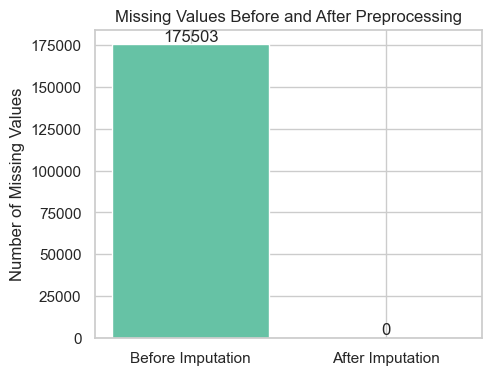

In [64]:
# Missing values before preprocessing
missing_before = X_train.isnull().sum().sum()

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)

# Missing values after preprocessing
if hasattr(X_train_processed, "toarray"):
    missing_after = np.isnan(X_train_processed.toarray()).sum()
else:
    missing_after = np.isnan(X_train_processed).sum()

# Plot
plt.figure(figsize=(5, 4))
plt.bar(["Before Imputation", "After Imputation"],
        [missing_before, missing_after])
plt.title("Missing Values Before and After Preprocessing")
plt.ylabel("Number of Missing Values")

for i, v in enumerate([missing_before, missing_after]):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.show()

## 10. Train Baseline and Tree-Based Models


This section develops and evaluates multiple machine learning classification
algorithms to identify the best-performing model for Type 2 diabetes risk
prediction.

The modelling workflow is organised into the following stages:

**Stage 1 — Baseline Model**
Logistic Regression is trained first to establish an interpretable performance
benchmark. All subsequent models must exceed this baseline on Recall and
ROC-AUC to justify their additional complexity.
ROC Curve (Receiver Operating Characteristic) is a graph plotting the True Positive Rate against the False Positive Rate across all possible classification thresholds

**Stage 2 — Tree-Based Classifiers**
A Decision Tree and a Random Forest are trained as non-linear alternatives
to the baseline, introducing ensemble learning and evaluating whether
bagging improves performance over a single tree.

**Stage 3 — Gradient Boosting Classifiers**
XGBoost is trained as sequential ensemble method,
representing the  approache for structured tabular data.

**Stage 4 — Initial Model Comparison**
All 4 models are compared across Accuracy
and ROC-AUC to identify performance patterns and configuration issues.

**Stage 5 — Hyperparameter Tuning**
Gradient boosting model is retrained with corrected configurations and
decision threshold optimisation is applied to maximise Recall on the
positive class.

**Stage 6 — Final Model Selection**
The best-performing model after tuning is selected, evaluated in full, and
prepared for the Explainability analysis.


## 10.1 Baseline model
### 10.1.1 Logistic regression

Logistic Regression
Accuracy: 0.7291
ROC-AUC: 0.8222
Recall: 0.7639
Precision: 0.3151
F1-Score: 0.4462
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     71742
           1       0.32      0.76      0.45     11957

    accuracy                           0.73     83699
   macro avg       0.63      0.74      0.63     83699
weighted avg       0.86      0.73      0.77     83699



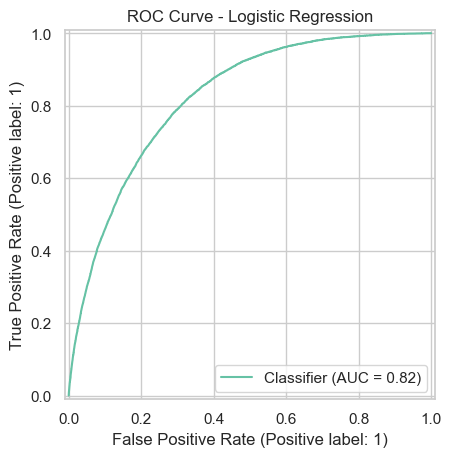

In [67]:
# Define and train the Logistic Regression model
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",# Handle class imbalance
        random_state=42
    ))
])

# Train the Logistic Regression model
log_reg.fit(X_train, y_train)

# Make predictions and evaluate the Logistic Regression model
log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
log_reg_roc_auc = roc_auc_score(y_test, log_reg_proba)

# Print evaluation metrics
print("Logistic Regression")
print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"ROC-AUC: {log_reg_roc_auc:.4f}")
print(f"Recall: {recall_score(y_test, log_reg_pred):.4f}")
print(f"Precision: {precision_score(y_test, log_reg_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, log_reg_pred):.4f}")
print(classification_report(y_test, log_reg_pred))

# Plot ROC curve for Logistic Regression
RocCurveDisplay.from_predictions(y_test, log_reg_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

- The Logistic Regression model achieved an accuracy of 72.91% and a ROC-AUC of 0.8222, indicating good overall classification performance. It correctly identified 76.39% of diabetes cases (recall), making it suitable for minimizing missed positive cases. However, the precision of 31.51% shows that many predicted positive cases were false positives. Overall, the model provides good sensitivity for diabetes detection but has limited precision in identifying true positive c
- On the ROC- AUC graph: The x-axis represents the False Positive Rate (FPR), while the y-axis represents the True Positive Rate (TPR). The ROC curve shows that the Logistic Regression model achieves a high TPR while maintaining a relatively low FPR, resulting in an AUC of 0.82.

## 10.2 Tree Based Models
Tree-based algorithms capture nonlinear relationships and feature interactions that cannot be represented by linear models. This section evaluates both a single decision tree and an ensemble Random Forest classifier.
### 10.2.1 Decision Tree

Decision Tree
Accuracy: 0.6803
Recall: 0.8057
Precision: 0.2828
F1-Score: 0.4187
ROC-AUC: 0.8024
              precision    recall  f1-score   support

           0       0.95      0.66      0.78     71742
           1       0.28      0.81      0.42     11957

    accuracy                           0.68     83699
   macro avg       0.62      0.73      0.60     83699
weighted avg       0.86      0.68      0.73     83699



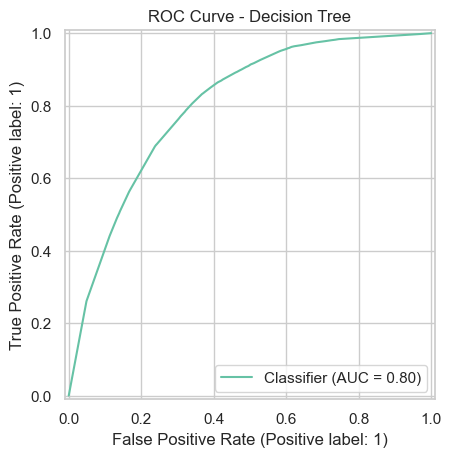

In [68]:
# Decision Tree Classifier
decision_tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        class_weight="balanced",# Handle class imbalance
        random_state=42
    ))
])

# Train the Decision Tree model
decision_tree.fit(X_train, y_train)

# Make predictions and evaluate the Decision Tree model
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_proba = decision_tree.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)
decision_tree_roc_auc = roc_auc_score(y_test, decision_tree_proba)

# Print evaluation metrics
print("Decision Tree")
print(f"Accuracy: {decision_tree_accuracy:.4f}")
print(f"Recall: {recall_score(y_test, decision_tree_pred):.4f}")
print(f"Precision: {precision_score(y_test, decision_tree_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, decision_tree_pred):.4f}")
print(f"ROC-AUC: {decision_tree_roc_auc:.4f}")
print(classification_report(y_test, decision_tree_pred))

# Plot ROC curve for Decision Tree
RocCurveDisplay.from_predictions(y_test, decision_tree_proba)
plt.title("ROC Curve - Decision Tree")
plt.show()

Interpretation
- The Decision Tree model achieved an accuracy of 68.03% and a ROC-AUC score of 0.8024, indicating good overall classification performance. It recorded a high recall of 80.57%, demonstrating its ability to correctly identify most diabetes cases. However, the precision of 28.28% indicates that many predicted positive cases were false positives, resulting in an F1-score of 41.87%. Overall, the model is effective at detecting individuals with diabetes but sacrifices precision and overall accuracy, making it less balanced than the Logistic Regression model.

ROC Curve Interpretation

- The ROC curve shows good discrimination (AUC = 0.80), although it performs slightly below the Logistic Regression model.

### 10.2.2 Random Forest

Random Forest
Accuracy: 0.7193
Recall: 0.7821
Precision: 0.3092
F1-Score: 0.4432
ROC-AUC: 0.8239
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     71742
           1       0.31      0.78      0.44     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



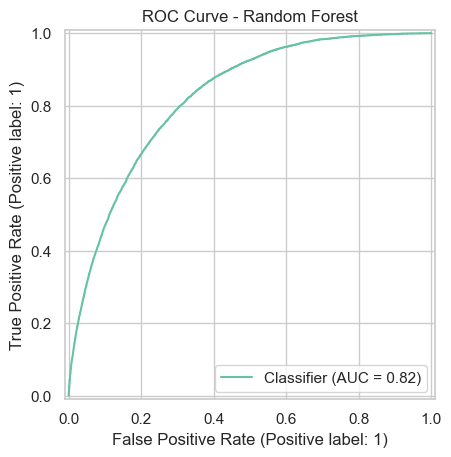

In [69]:
# Random Forest Classifier
random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        class_weight="balanced",# Handle class imbalance
        random_state=42,
        n_jobs=-1
    ))
])

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions and evaluate the Random Forest model
random_forest_pred = random_forest.predict(X_test)
random_forest_proba = random_forest.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
random_forest_roc_auc = roc_auc_score(y_test, random_forest_proba)

# Print evaluation metrics
print("Random Forest")
print(f"Accuracy: {random_forest_accuracy:.4f}")
print(f"Recall: {recall_score(y_test, random_forest_pred):.4f}")
print(f"Precision: {precision_score(y_test, random_forest_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, random_forest_pred):.4f}")
print(f"ROC-AUC: {random_forest_roc_auc:.4f}")
print(classification_report(y_test, random_forest_pred))

# Plot ROC curve for Random Forest
RocCurveDisplay.from_predictions(y_test, random_forest_proba)
plt.title("ROC Curve - Random Forest")
plt.show()

Interpretation

- The Random Forest model achieved an accuracy of 71.93% and a ROC-AUC score of 0.8239, indicating strong overall classification performance. It achieved a recall of 78.21%, demonstrating its ability to correctly identify most diabetes cases, while the precision of 30.92% indicates that a considerable number of predicted positive cases were false positives. The model recorded an F1-score of 44.32%, reflecting a moderate balance between precision and recall. Overall, Random Forest provided strong discrimination between the two classes and performed slightly better than Logistic Regression in terms of ROC-AUC, making it a competitive model for diabetes prediction.

ROC Curve Interpretation

- The ROC curve indicates good discrimination (AUC = 0.82), with performance comparable to Logistic Regression and better than the Decision Tree.

## 10.3 Gradient Boosting Classififier
Gradient boosting methods iteratively combine weak learners to minimize prediction errors. These models often achieve higher performance on structured tabular datasets and therefore constitute the primary high-performance models evaluated in this project.
### 10.3.1 XGBoost 

Use of scale_pos_weight
- The scale_pos_weight parameter is calculated by dividing the number of negative class samples (0) by the number of positive class samples (1) in the training dataset. In the expression scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), (y_train == 0).sum() counts the total number of negative instances, while (y_train == 1).sum() counts the total number of positive instances. The resulting ratio represents how much more common the majority class is compared to the minority class. This value is used in this algorithm to assign greater importance to the minority class during model training, helping to reduce the bias toward the majority class. By increasing the penalty for misclassifying positive cases, scale_pos_weight improves the model's ability to identify minority class instances, making it particularly useful for imbalanced classification problems such as diabetes prediction.

XGBoost
Accuracy: 0.7198
Recall: 0.7961
Precision: 0.3117
F1-Score: 0.4480
ROC-AUC: 0.8291
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     71742
           1       0.31      0.80      0.45     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



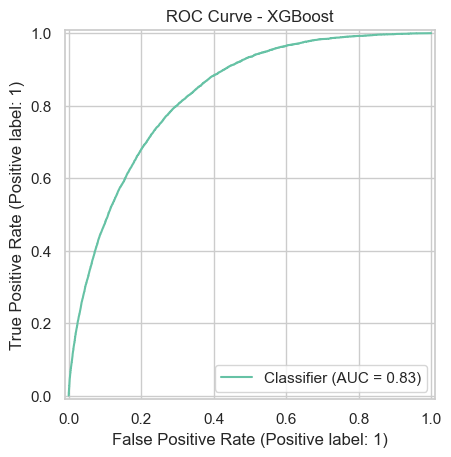

In [70]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance by 
# calculating the ratio of negative to positive samples in the training set
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initializing and training the XGBoost model with the calculated scale_pos_weight
xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,# Handle class imbalance
        eval_metric="logloss",# Evaluation metric for binary classification
        random_state=42,
        n_jobs=-1
    ))
])
# Train the XGBoost model
xgboost_model.fit(X_train, y_train)

# Make predictions and evaluate the XGBoost model
xgboost_pred = xgboost_model.predict(X_test)
xgboost_proba = xgboost_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
xgboost_accuracy = accuracy_score(y_test, xgboost_pred)
xgboost_roc_auc = roc_auc_score(y_test, xgboost_proba)

# Print evaluation metrics
print("XGBoost")
print(f"Accuracy: {xgboost_accuracy:.4f}")
print(f"Recall: {recall_score(y_test, xgboost_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgboost_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, xgboost_pred):.4f}")
print(f"ROC-AUC: {xgboost_roc_auc:.4f}")
print(classification_report(y_test, xgboost_pred))

# Plot ROC curve for XGBoost
RocCurveDisplay.from_predictions(y_test, xgboost_proba)
plt.title("ROC Curve - XGBoost")
plt.show()

Interpretation
- The XGBoost model achieved an accuracy of 71.98% and the highest ROC-AUC score of 0.8291, indicating the strongest overall ability to distinguish between diabetes and non-diabetes cases. It achieved a recall of 79.61%, correctly identifying most individuals with diabetes, while a precision of 31.17% indicates that many predicted positive cases were false positives. The model recorded an F1-score of 44.80%, reflecting a moderate balance between precision and recall. Overall, XGBoost demonstrated the best overall performance among the evaluated models, particularly in terms of ROC-AUC and recall, making it the most suitable model for diabetes prediction.

ROC Curve Interpretation

- The ROC curve demonstrates excellent discrimination (AUC = 0.83), outperforming the Logistic Regression, Decision Tree, and Random Forest models.

### 10.3.2 LightGBM

LightGBM
Accuracy: 0.7157
Recall: 0.7991
Precision: 0.3087
F1-Score: 0.4454
ROC-AUC: 0.8291
              precision    recall  f1-score   support

           0       0.95      0.70      0.81     71742
           1       0.31      0.80      0.45     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



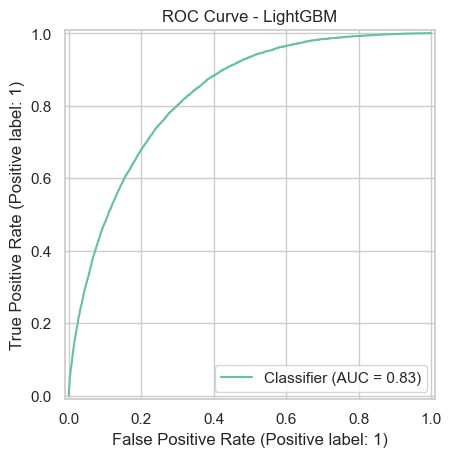

In [88]:
# Calculate scale_pos_weight to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize and train the LightGBM model
lightgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

# Train the model
lightgbm_model.fit(X_train, y_train)

# Make predictions
lightgbm_pred = lightgbm_model.predict(X_test)
lightgbm_proba = lightgbm_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
lightgbm_accuracy = accuracy_score(y_test, lightgbm_pred)
lightgbm_roc_auc = roc_auc_score(y_test, lightgbm_proba)

# Print evaluation metrics
print("LightGBM")
print(f"Accuracy: {lightgbm_accuracy:.4f}")
print(f"Recall: {recall_score(y_test, lightgbm_pred):.4f}")
print(f"Precision: {precision_score(y_test, lightgbm_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lightgbm_pred):.4f}")
print(f"ROC-AUC: {lightgbm_roc_auc:.4f}")
print(classification_report(y_test, lightgbm_pred))

# Plot ROC curve
RocCurveDisplay.from_predictions(y_test, lightgbm_proba)
plt.title("ROC Curve - LightGBM")
plt.show()

The LightGBM model achieved an accuracy of 71.57%, a recall of 79.91%, a precision of 30.87%, an F1-score of 44.54%, and a ROC-AUC of 0.8291, demonstrating strong overall classification performance. The high recall indicates that the model was effective at correctly identifying individuals with diabetes, making it suitable for a medical screening task where minimizing missed positive cases is important. However, the relatively low precision suggests that a considerable number of non-diabetic individuals were incorrectly classified as having diabetes, resulting in a higher false-positive rate. The F1-score reflects a moderate balance between precision and recall. Overall, LightGBM performed comparably to XGBoost, achieving the same ROC-AUC while maintaining high recall, indicating its strong ability to distinguish between diabetic and non-diabetic individuals.

## 11. Best Model Evaluation


In [89]:
# Summarize model performance metrics in a DataFrame
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        log_reg_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgboost_accuracy,
        lightgbm_accuracy
    ],
    "ROC-AUC": [
        log_reg_roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        xgboost_roc_auc,
        lightgbm_roc_auc
    ],
    "Recall": [
        recall_score(y_test, log_reg_pred),
        recall_score(y_test, decision_tree_pred),
        recall_score(y_test, random_forest_pred),
        recall_score(y_test, xgboost_pred),
        recall_score(y_test, lightgbm_pred)
    ],
    "Precision": [
        precision_score(y_test, log_reg_pred),
        precision_score(y_test, decision_tree_pred),
        precision_score(y_test, random_forest_pred),
        precision_score(y_test, xgboost_pred),
        precision_score(y_test, lightgbm_pred)
    ],
    "F1-Score": [
        f1_score(y_test, log_reg_pred),
        f1_score(y_test, decision_tree_pred),
        f1_score(y_test, random_forest_pred),
        f1_score(y_test, xgboost_pred),
        f1_score(y_test, lightgbm_pred)
    ]
})

# Display the results sorted by ROC-AUC
results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC,Recall,Precision,F1-Score
3,XGBoost,0.719770,0.829129,0.796103,0.311730,0.448027
4,LightGBM,0.715696,0.829117,0.799113,0.308734,0.445392
2,Random Forest,0.719280,0.823881,0.782136,0.309229,0.443223
0,Logistic Regression,0.729065,0.822202,0.763904,0.315096,0.446159
1,Decision Tree,0.680331,0.802421,0.805720,0.282796,0.418651


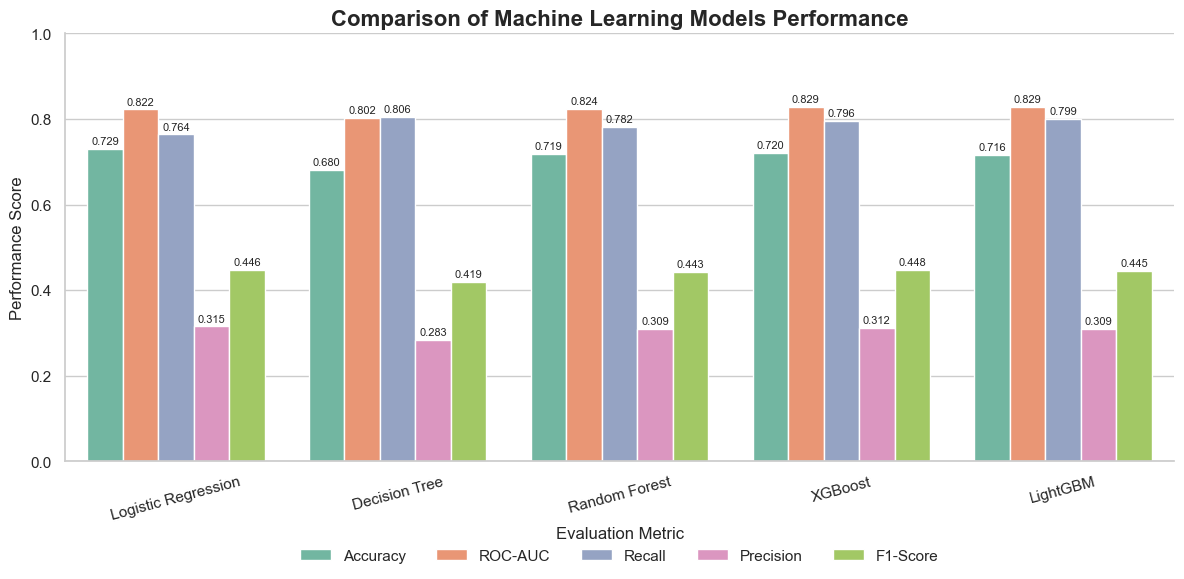

In [90]:
# Plot 
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "ROC-AUC", "Recall", "Precision", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

# Plot style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2",
)

# Formatting
plt.title("Comparison of Machine Learning Models Performance", fontsize=16, weight="bold")
plt.xlabel("")
plt.ylabel("Performance Score", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Evaluation Metric", loc="upper center",
           bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

# Clean up
sns.despine()
plt.tight_layout()

plt.show()

- The chart compares the performance of Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM across five evaluation metrics: **Accuracy, ROC-AUC, Recall, Precision, and F1-Score**.
- XGBoost achieved the best overall performance, recording the highest ROC-AUC (0.829) and F1-score (0.448) while maintaining high accuracy (0.720) and recall (0.796).
- LightGBM performed similarly to XGBoost, achieving the same ROC-AUC (0.829) and a slightly higher recall (0.799), although its accuracy (0.716) and F1-score (0.445) were marginally lower.
- Random Forest also demonstrated strong performance, with a ROC-AUC of 0.824, accuracy of 0.719, and recall of 0.782, making it a competitive alternative.
- Logistic Regression achieved the highest accuracy (0.729) but had a slightly lower recall and ROC-AUC than the boosting models.
- Decision Tree recorded the highest recall (0.806), indicating strong ability to detect diabetes cases, but had the lowest accuracy (0.680), precision (0.283), and F1-score (0.419), reflecting a higher false-positive rate.
- Precision was consistently low across all models (0.283–0.315), indicating that while the models effectively identified diabetes cases, they also produced a considerable number of false-positive predictions.
- Overall, XGBoost and LightGBM were the best-performing models, providing the strongest balance between discrimination ability (ROC-AUC), sensitivity (recall), and overall predictive performance for diabetes prediction.

### Hyperparameter tuning best model
After evaluating the performance of all candidate models, the best-performing model was selected for hyperparameter tuning using GridSearchCV. GridSearchCV systematically evaluates all possible combinations of predefined hyperparameter values through cross-validation to identify the configuration that yields the best model performance. This approach helps optimize the model by selecting the hyperparameters that maximize the chosen evaluation metric while reducing the risk of overfitting. Once the optimal hyperparameters were identified, the model was retrained using the best parameter combination and subsequently evaluated on the test dataset to assess its final predictive performance.

In [79]:
# Define the scale_pos_weight for XGBoost to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define the XGBoost pipeline with preprocessing and model
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

In [99]:
# Define the hyperparameter grid for XGBoost
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [100]:
# Perform grid search with cross-validation for XGBoost
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit the grid search to the training data
xgb_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


The XGBoost hyperparameter tuning process evaluated 72 parameter combinations using 3-fold cross-validation, resulting in 216 total model fits. This allows the model to search across different tree depths, learning rates, numbers of estimators, and sampling settings to identify the parameter combination with the best cross-validated ROC-AUC score.

In [101]:
# Display the best ROC-AUC score and the best hyperparameters found during grid search
print("Best ROC-AUC:", xgb_grid_search.best_score_)
print("Best parameters:")
print(xgb_grid_search.best_params_)

Best ROC-AUC: 0.8315679542251466
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [102]:
# Evaluate the best XGBoost model on the test set
best_xgb = xgb_grid_search.best_estimator_

best_xgb_pred = best_xgb.predict(X_test)
best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

best_xgb_accuracy = accuracy_score(y_test, best_xgb_pred)
best_xgb_roc_auc = roc_auc_score(y_test, best_xgb_proba)

# Print evaluation metrics for the best XGBoost model
print("Tuned XGBoost")
print(f"Accuracy: {best_xgb_accuracy:.4f}")
print(f"Recall: {recall_score(y_test, best_xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_xgb_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, best_xgb_pred):.4f}")
print(f"ROC-AUC: {best_xgb_roc_auc:.4f}")
print(classification_report(y_test, best_xgb_pred))

Tuned XGBoost
Accuracy: 0.7198
Recall: 0.7951
Precision: 0.3116
F1-Score: 0.4477
ROC-AUC: 0.8294
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     71742
           1       0.31      0.80      0.45     11957

    accuracy                           0.72     83699
   macro avg       0.63      0.75      0.63     83699
weighted avg       0.86      0.72      0.76     83699



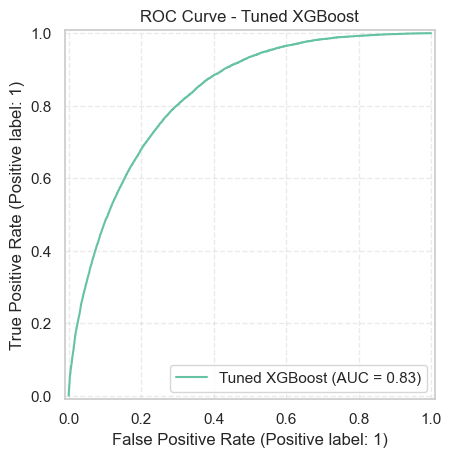

In [54]:
# Plot the ROC curve for the tuned XGBoost model
RocCurveDisplay.from_predictions(
    y_test,
    best_xgb_proba,
    name="Tuned XGBoost"
)

plt.title("ROC Curve - Tuned XGBoost")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

The tuned XGBoost model achieved an accuracy of 71.98% and a ROC-AUC of 0.8294, indicating excellent overall classification performance. It correctly identified 79.51% of diabetes cases (recall), while a precision of 31.16% indicates that many predicted positive cases were false positives. The F1-score of 44.77% reflects a moderate balance between precision and recall. Compared with the original XGBoost model, hyperparameter tuning resulted in only a marginal improvement in ROC-AUC, with the remaining performance metrics remaining virtually unchanged.

In [103]:
# Compare the original and tuned XGBoost models
xgb_comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "Accuracy": [xgboost_accuracy, best_xgb_accuracy],
    "Recall": [recall_score(y_test, xgboost_pred), recall_score(y_test, best_xgb_pred)],
    "Precision": [precision_score(y_test, xgboost_pred), precision_score(y_test, best_xgb_pred)],
    "F1-Score": [f1_score(y_test, xgboost_pred), f1_score(y_test, best_xgb_pred)],
    "ROC-AUC": [xgboost_roc_auc, best_xgb_roc_auc]
})

xgb_comparison

,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC
0,Original XGBoost,0.719770,0.796103,0.311730,0.448027,0.829129
1,Tuned XGBoost,0.719758,0.795099,0.311572,0.447704,0.829408


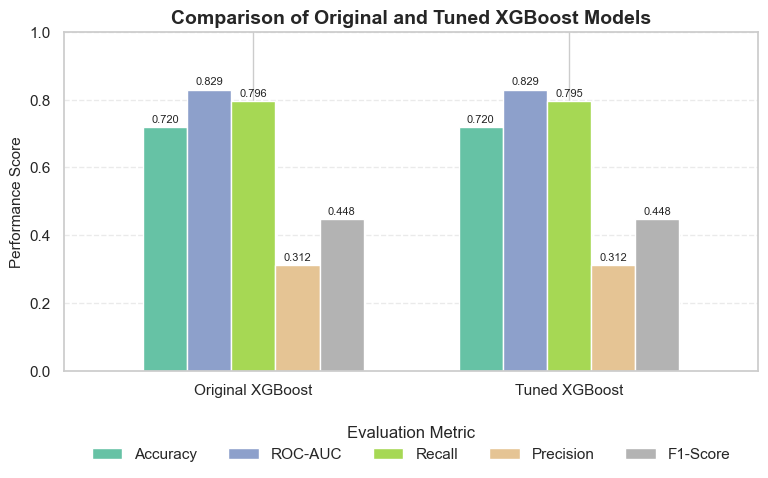

In [109]:
ax = xgb_comparison.plot(
    x="Model",
    y=["Accuracy", "ROC-AUC", "Recall", "Precision", "F1-Score"],
    kind="bar",
    figsize=(8, 5),
    colormap="Set2",
    width=0.7
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.title("Comparison of Original and Tuned XGBoost Models", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Performance Score", fontsize=11)
plt.ylim(0, 1)
plt.xticks(rotation=0)

# Place legend below the plot
plt.legend(
    title="Evaluation Metric",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

# Light horizontal grid
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Interpretation
- The chart compares the performance of the original and tuned XGBoost models across five evaluation metrics: Accuracy, ROC-AUC, Recall, Precision, and F1-Score.
- Both models achieved the same accuracy (0.720), indicating that hyperparameter tuning did not improve the overall classification accuracy.
- The ROC-AUC remained virtually unchanged (0.829), showing that tuning produced only a negligible improvement in the model's ability to distinguish between diabetic and non-diabetic individuals.
- The original XGBoost model recorded a slightly higher recall (0.796 vs. 0.795) and F1-score (0.448 vs. 0.448), while precision (0.312) remained identical for both models.
- The differences between the two models are minimal across all evaluation metrics, indicating that hyperparameter tuning had little impact on predictive performance.
- Overall, the original XGBoost model was already well-optimized, and the tuned model did not provide a meaningful performance improvement.

## 12. Feature Importance and Interpretation


In [110]:
# Get the feature names after preprocessing for the best XGBoost model
best_xgb.named_steps["preprocessor"].get_feature_names_out()

array(['num__BMI', 'num__Age', 'num__Physical_Health', 'cat__Sex_1.0',
       'cat__Sex_2.0', 'cat__Race_Ethnicity_1.0',
       'cat__Race_Ethnicity_2.0', 'cat__Race_Ethnicity_3.0',
       'cat__Race_Ethnicity_4.0', 'cat__Race_Ethnicity_5.0',
       'cat__Race_Ethnicity_6.0', 'cat__General_Health_Excellent',
       'cat__General_Health_Fair', 'cat__General_Health_Good',
       'cat__General_Health_Poor', 'cat__General_Health_Very Good',
       'cat__Ever_Smoked_0.0', 'cat__Ever_Smoked_1.0',
       'cat__Physical_Activity_0.0', 'cat__Physical_Activity_1.0',
       'cat__Education_Level_1.0', 'cat__Education_Level_2.0',
       'cat__Education_Level_3.0', 'cat__Education_Level_4.0',
       'cat__Education_Level_5.0', 'cat__Education_Level_6.0',
       'cat__Income_Level_1.0', 'cat__Income_Level_2.0',
       'cat__Income_Level_3.0', 'cat__Income_Level_4.0',
       'cat__Income_Level_5.0', 'cat__Income_Level_6.0',
       'cat__Income_Level_7.0', 'cat__Income_Level_8.0',
       'cat__Income_

In [112]:
# Map the feature names to more readable labels
feature_names = (
    pd.Series(best_xgb.named_steps["preprocessor"].get_feature_names_out())

    # Remove transformer prefixes
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("missing_flags__", "", regex=False)

    # Binary variables to more descriptive labels
    .str.replace("Hypertension_0.0", "Hypertension: No", regex=False)
    .str.replace("Hypertension_1.0", "Hypertension: Yes", regex=False)

    .str.replace("High_Cholesterol_0.0", "High Cholesterol: No", regex=False)
    .str.replace("High_Cholesterol_1.0", "High Cholesterol: Yes", regex=False)

    .str.replace("Ever_Smoked_0.0", "Ever Smoked: No", regex=False)
    .str.replace("Ever_Smoked_1.0", "Ever Smoked: Yes", regex=False)

    .str.replace("Physical_Activity_0.0", "Physical Activity: No", regex=False)
    .str.replace("Physical_Activity_1.0", "Physical Activity: Yes", regex=False)

    .str.replace("Heart_Disease_0.0", "Heart Disease: No", regex=False)
    .str.replace("Heart_Disease_1.0", "Heart Disease: Yes", regex=False)

    .str.replace("Kidney_Disease_Kidney Disease", "Kidney Disease: Yes", regex=False)
    .str.replace("Kidney_Disease_No Kidney Disease", "Kidney Disease: No", regex=False)

    # Multi-category variables
    .str.replace("General_Health_", "General Health: ", regex=False)
    .str.replace("Race_Ethnicity_", "Race/Ethnicity: ", regex=False)
    .str.replace("Education_Level_", "Education Level: ", regex=False)
    .str.replace("Income_Level_", "Income Level: ", regex=False)

    # Missing indicators
    .str.replace("Income_Level_missing", "Income Missing", regex=False)
    .str.replace("High_Cholesterol_missing", "High Cholesterol Missing", regex=False)
    .str.replace("BMI_missing", "BMI Missing", regex=False)
    .str.replace("Ever_Smoked_missing", "Smoking Missing", regex=False)

    .tolist()
)

In [113]:
# Get the trained XGBoost model
xgb_model = best_xgb.named_steps["model"]

# Create feature importance DataFrame
feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": xgb_model.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Display the top 10 features
feature_importance.head(10)

,Feature,Importance
0,Hypertension: Yes,0.416111
1,Hypertension: No,0.205907
2,General Health: Very Good,0.049979
3,High Cholesterol: Yes,0.038023
4,General Health: Excellent,0.037874
5,High Cholesterol: No,0.025171
6,Age,0.022515
7,General Health: Good,0.018991
8,General Health: Fair,0.016368
9,Kidney Disease: Yes,0.015572


In [114]:
# Aggregate one-hot encoded features
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .replace({
        r"General Health:.*": "General Health",
        r"Hypertension:.*": "Hypertension",
        r"High Cholesterol:.*": "High Cholesterol",
        r"Kidney Disease:.*": "Kidney Disease",
        r"Heart Disease:.*": "Heart Disease",
        r"Physical Activity:.*": "Physical Activity",
        r"Ever Smoked:.*": "Ever Smoked",
        r"Race/Ethnicity:.*": "Race/Ethnicity",
        r"Education Level:.*": "Education Level",
        r"Income Level:.*": "Income Level",
    }, regex=True)
)

feature_importance_grouped = (
    feature_importance
    .groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

feature_importance_grouped

,Feature,Importance
9,Hypertension,0.622018
5,General Health,0.134457
7,High Cholesterol,0.063193
12,Physical Activity,0.026750
0,Age,0.022515
11,Kidney Disease,0.022236
6,Heart Disease,0.020992
14,Race/Ethnicity,0.020026
10,Income Level,0.018504
3,Education Level,0.016285


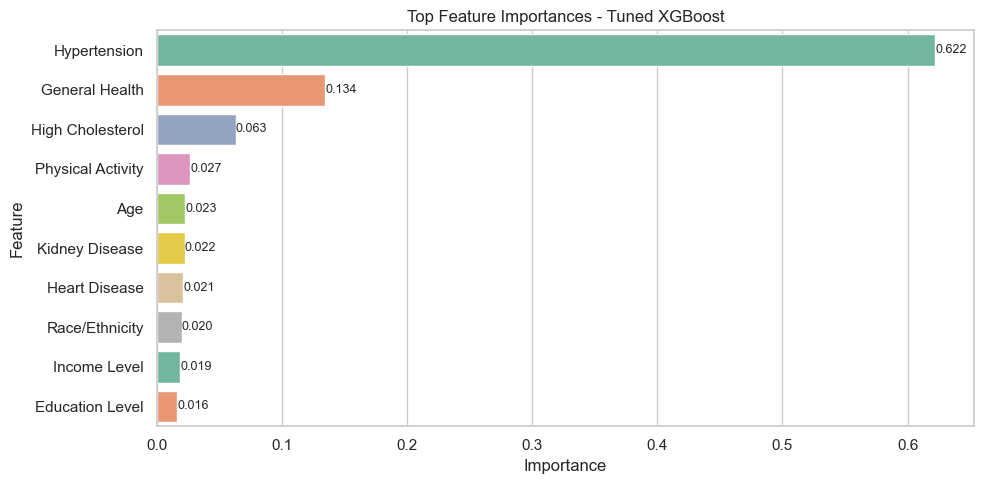

In [115]:
# Top 10 features
top_features = feature_importance_grouped.head(10)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="Set2"
)

# Title and labels
plt.title("Top Feature Importances - Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Annotate bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.3f}",
            (width, p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

The tuned XGBoost model identified hypertension status as the most important predictor of diabetes risk, with an importance score of 0.368. This feature contributed far more than any other variable, suggesting that blood-pressure status is highly informative for distinguishing between respondents with and without diabetes.

General health and cholesterol status were also among the strongest predictors. Several general-health categories appeared in the top features, showing that self-reported health captures meaningful differences in diabetes risk. Cholesterol status, kidney disease, heart disease, physical inactivity, age, BMI, race/ethnicity, education, and income also contributed to the model, although with lower importance scores.

Overall, the feature importance results align well with the EDA findings: diabetes risk is strongly associated with cardiometabolic factors such as hypertension, cholesterol, BMI, kidney disease, heart disease, and age. These results support using the model as a risk-screening tool while also emphasizing the importance of preventive care for adults with multiple cardiometabolic risk factors.

### Modeling Insights


- All models performed well, with ROC-AUC scores above 0.80, showing that BRFSS variables can predict diabetes risk.

- XGBoost performed best with the highest ROC-AUC score of 0.829, followed closely by Random Forest at 0.824.

- Logistic Regression had strong performance and the highest accuracy score of 0.729, making it a useful interpretable baseline.

- Decision Tree performed weakest, likely because a single tree is less stable than ensemble models.

- Feature importance showed hypertension as the strongest predictor, followed by general health, cholesterol, kidney disease, heart disease, age, BMI, and physical activity.

- XGBoost is the preferred final model, but recall and ROC-AUC should be prioritized because diabetes is the minority class.

## 13. Global and Local Interpretability

### LIME AND SHARP
To improve model interpretability, SHAP and LIME were applied to the tuned XGBoost model.
SHAP explains overall feature importance, while LIME explains individual predictions. Together, they improve the interpretability of the tuned XGBoost model.

### 13.1. SHAP(SHapley Additive exPlanations)
SHAP was used to explain the tuned XGBoost model globally by showing which features contributed most to predictions across the test set.

In [116]:
# Transform data using the fitted preprocessor
X_train_transformed = best_xgb.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)

# Get feature names after preprocessing
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

# Convert sparse matrix to dense
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

# Get trained XGBoost model
xgb_final_model = best_xgb.named_steps["model"]

In [117]:
# SHAP explanation using generic Explainer

shap_explainer = shap.Explainer(
    xgb_final_model.predict,
    X_train_transformed,
    feature_names=feature_names
)

shap_values = shap_explainer(X_test_transformed[:1000])

PermutationExplainer explainer: 1001it [00:36, 23.50it/s]                         


In [118]:
# Map feature names to more readable labels for SHAP plots
feature_names = (
    pd.Series(best_xgb.named_steps["preprocessor"].get_feature_names_out())

    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("missing_flags__", "", regex=False)

    # Sex
    .str.replace("Sex_1.0", "Sex: Male", regex=False)
    .str.replace("Sex_2.0", "Sex: Female", regex=False)

    # Race
    .str.replace("Race_Ethnicity_1.0", "Race/Ethnicity: White", regex=False)
    .str.replace("Race_Ethnicity_2.0", "Race/Ethnicity: Black", regex=False)
    .str.replace("Race_Ethnicity_3.0", "Race/Ethnicity: American Indian/Alaska Native", regex=False)
    .str.replace("Race_Ethnicity_4.0", "Race/Ethnicity: Asian", regex=False)
    .str.replace("Race_Ethnicity_5.0", "Race/Ethnicity: Native Hawaiian/Pacific Islander", regex=False)
    .str.replace("Race_Ethnicity_6.0", "Race/Ethnicity: Other", regex=False)

    # Education
    .str.replace("Education_Level_1.0", "Education: Never Attended School", regex=False)
    .str.replace("Education_Level_2.0", "Education: Elementary", regex=False)
    .str.replace("Education_Level_3.0", "Education: Some High School", regex=False)
    .str.replace("Education_Level_4.0", "Education: High School Graduate", regex=False)
    .str.replace("Education_Level_5.0", "Education: Some College", regex=False)
    .str.replace("Education_Level_6.0", "Education: College Graduate", regex=False)

    # Income
    .str.replace("Income_Level_1.0", "Income: <$10,000", regex=False)
    .str.replace("Income_Level_2.0", "Income: $10k-$15k", regex=False)
    .str.replace("Income_Level_3.0", "Income: $15k-$20k", regex=False)
    .str.replace("Income_Level_4.0", "Income: $20k-$25k", regex=False)
    .str.replace("Income_Level_5.0", "Income: $25k-$35k", regex=False)
    .str.replace("Income_Level_6.0", "Income: $35k-$50k", regex=False)
    .str.replace("Income_Level_7.0", "Income: $50k-$75k", regex=False)
    .str.replace("Income_Level_8.0", "Income: $75k-$100k", regex=False)
    .str.replace("Income_Level_9.0", "Income: $100k-$150k", regex=False)
    .str.replace("Income_Level_10.0", "Income: >$150k", regex=False)

    # Hypertension
    .str.replace("Hypertension_0.0", "Hypertension: No", regex=False)
    .str.replace("Hypertension_1.0", "Hypertension: Yes", regex=False)

    # High cholesterol
    .str.replace("High_Cholesterol_0.0", "High Cholesterol: No", regex=False)
    .str.replace("High_Cholesterol_1.0", "High Cholesterol: Yes", regex=False)

    # Smoking
    .str.replace("Ever_Smoked_0.0", "Ever Smoked: No", regex=False)
    .str.replace("Ever_Smoked_1.0", "Ever Smoked: Yes", regex=False)

    # Physical activity
    .str.replace("Physical_Activity_0.0", "Physical Activity: No", regex=False)
    .str.replace("Physical_Activity_1.0", "Physical Activity: Yes", regex=False)

    # General health
    .str.replace("General_Health_", "General Health: ", regex=False)

    # Kidney disease
    .str.replace("Kidney_Disease_Kidney Disease", "Kidney Disease: Yes", regex=False)
    .str.replace("Kidney_Disease_No Kidney Disease", "Kidney Disease: No", regex=False)

    # Heart disease
    .str.replace("Heart_Disease_0.0", "Heart Disease: No", regex=False)
    .str.replace("Heart_Disease_1.0", "Heart Disease: Yes", regex=False)

    # Physical health
    .str.replace("Physical_Health", "Physical Health (days)", regex=False)

    .tolist()
)

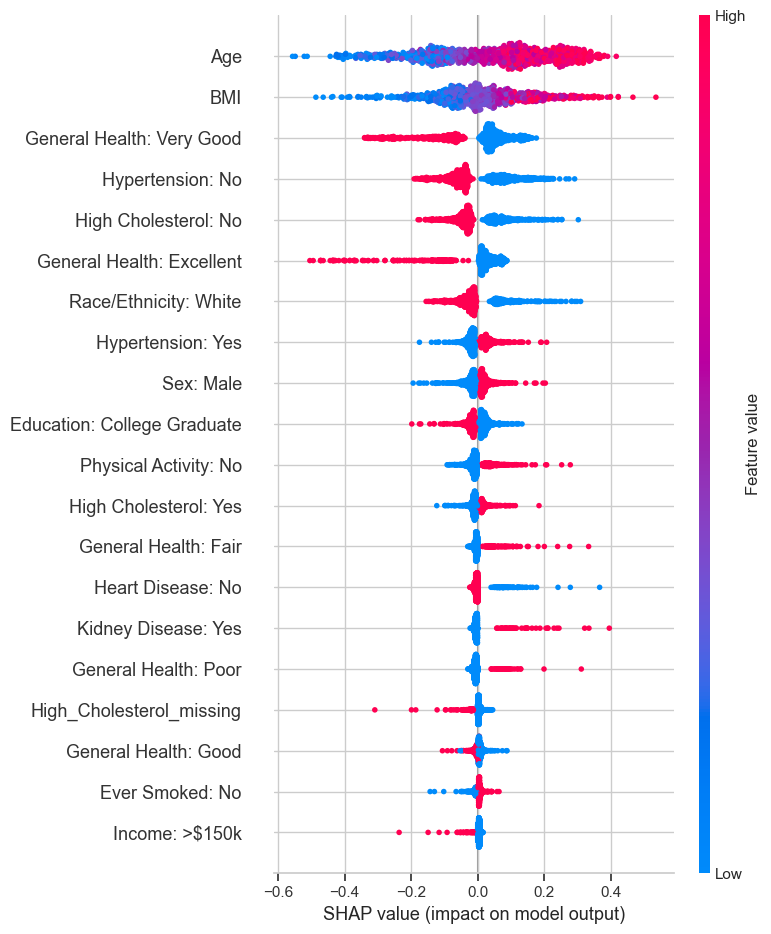

In [119]:
# SHAP summary plot
shap.summary_plot(
    shap_values.values,
    X_test_transformed[:1000],
    feature_names=feature_names
)

SHAP values explain the impact of each feature on the model's prediction for individual instances.

- Positive SHAP values (red/right side) → Increase diabetes risk prediction

- Negative SHAP values (blue/left side) → Decrease diabetes risk prediction

- Color represents the feature value (red = high, blue = low)

### Feature-Specific Insights from SHAP

| Feature | Importance | SHAP Insight |
|---------|------------|--------------|
| **Age** | Highest | Older age increases diabetes risk. |
| **Hypertension** | High | Hypertension increases risk. |
| **BMI** | High | Higher BMI increases risk. |
| **General Health** | High | Poor health increases risk. |
| **High Cholesterol** | High | High cholesterol increases risk. |
| **Physical Activity** | Moderate | Physical activity reduces risk. |
| **Education level** | Moderate | Higher education slightly reduces risk. |
| **Income level** | Moderate | Higher income slightly reduces risk. |
| **Heart Disease** | Moderate | Heart disease increases risk. |
| **Kidney Disease** | Moderate | Kidney disease increases risk. |

### 13.2. LIME (Local Interpretable Model-Agnostic Explanations)
LIME was used to explain individual predictions by showing which features pushed a specific respondent's prediction toward diabetes or no diabetes.

In [120]:
# LIME explanation using LimeTabularExplainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)


In [121]:
i = 30  # Randomly selected index to explain a specific instance from the test set.

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_transformed[i],
    predict_fn=xgb_final_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

### LIME Individual Prediction Insight


- The LIME explanation shows that the model predicted a 68% probability of diabetes for this individual. 
- The prediction was driven primarily by age and BMI, which were the strongest contributors, followed by hypertension status, cholesterol status, race/ethnicity, and heart disease status. 
- Other variables, including general health, smoking history, and kidney disease, had comparatively smaller effects on the prediction.

| Feature | Contribution | Interpretation |
|---------|-------------:|---------------|
| **Age** | **0.13** | Strongest contributor; older age increased the predicted diabetes risk. |
| **BMI** | **0.08** | Higher BMI increased the predicted diabetes risk. |
| **Hypertension: No** | **0.04** | Small contribution; reflects one-hot encoding of hypertension status. |
| **High Cholesterol: No** | **0.04** | Moderate contribution to the prediction. |
| **Race/Ethnicity: White** | **0.03** | Slight contribution to the prediction. |
| **Heart Disease: No** | **0.03** | Small contribution to the prediction. |
| **General Health: Very Good** | **0.02** | Minor influence on the prediction. |
| **Hypertension: Yes** | **0.01** | Small contribution; represents hypertension status. |
| **Ever Smoked: No** | **0.01** | Minimal influence on the prediction. |
| **Kidney Disease: No** | **0.01** | Minimal influence on the prediction. |

The table below the chart shows the values of the transformed features used by the model.
  - Age = -0.13
  - BMI = -0.14
These are standardized values, not the individual's actual age or BMI. Negative values indicate that the individual's value is below the average of the training dataset after scaling.




## 14. Model Deployment using Streamlit

After selecting the tuned XGBoost model as the final model, it was deployed using Streamlit, an open-source Python framework for building interactive web applications. The trained model was serialized using joblib and integrated into a Streamlit application. The application allows users to enter patient information, including demographic, lifestyle, and health-related factors, through an intuitive interface. These inputs are processed and passed to the trained model, which predicts the likelihood of Type 2 Diabetes and returns both the predicted class and the probability score. Deploying the model through Streamlit makes it accessible to end users without requiring knowledge of machine learning or programming.

### Deployment Workflow

1. **User Input** – The user enters demographic, lifestyle, and health information.
2. **Streamlit Interface** – The application collects and validates the inputs.
3. **Input Preprocessing** – The inputs are formatted to match the model's expected features.
4. **Trained XGBoost Model (.pkl)** – The preprocessed data is passed to the saved model.
5. **Prediction & Probability** – The model predicts diabetes risk and computes the probability.
6. **Display Results** – The application presents the prediction and risk probability to the user.

In [122]:
# Save the tuned XGBoost model to a file for use in Streamlit app
joblib.dump(best_xgb, "tuned_xgboost.pkl")

['tuned_xgboost.pkl']

In [123]:
# Check the columns of the training data for reference in the Streamlit app
X_train.columns.tolist()

['BMI',
 'Age',
 'Sex',
 'Race_Ethnicity',
 'General_Health',
 'Physical_Health',
 'Ever_Smoked',
 'Physical_Activity',
 'Education_Level',
 'Income_Level',
 'Hypertension',
 'High_Cholesterol',
 'Kidney_Disease',
 'Heart_Disease',
 'Income_Level_missing',
 'High_Cholesterol_missing',
 'BMI_missing',
 'Ever_Smoked_missing']

In [ ]:
# Create app.py for Streamlit deployment with the required code to
#  load the model and make predictions based on user input.

In [1]:
# Launch Streamlit app
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


## 15. Project Insights

- **Age** was the strongest predictor of Type 2 Diabetes, with risk increasing among older individuals.

- **Hypertension, high BMI, poor general health, and high cholesterol** were the key clinical risk factors associated with diabetes.

- **Physical activity** reduced diabetes risk, while higher **education** and **income** were associated with a slightly lower risk.

- **Tuned XGBoost** achieved the best overall performance, with an **Accuracy of 72.03%** and a **ROC-AUC of 0.8293**.

- All models achieved **high recall (≥0.76)**, effectively identifying diabetes cases, although precision remained relatively low due to false positives.

- **Hyperparameter tuning** slightly improved XGBoost performance, confirming it as the final model.

- **SHAP** identified **age, hypertension, BMI, general health, and high cholesterol** as the most influential features.

- **LIME** provided local explanations, showing how individual features influenced specific predictions.

- The findings demonstrate that machine learning can support the **early identification of individuals at high risk of Type 2 Diabetes**, enabling timely preventive interventions.

## 16. Recommendations

1. **Prioritize screening for adults with multiple clinical risk factors.** Respondents with hypertension, high cholesterol, high BMI, kidney disease, or heart disease show elevated diabetes prevalence and should be strong candidates for follow-up screening.
2. **Use the model as a risk-stratification support tool, not a diagnosis.** The output should guide outreach and preventive-care prioritization; diagnosis still requires clinical testing.
3. **Tune the decision threshold to the operational goal.** If the program goal is early detection, choose a threshold that improves diabetes recall, accepting more false positives.
4. **Pair model outputs with intervention pathways.** Risk identification is most useful when connected to A1C testing, nutrition counseling, physical-activity programs, blood-pressure management, and cholesterol management.
5. **Monitor fairness and subgroup performance.** Because diabetes burden and healthcare access vary across demographic groups, evaluate recall, precision, and false-positive rates across race/ethnicity, sex, and age groups before deployment.


## 17. Conclusion

The BRFSS variables provide a useful foundation for predicting Type 2 diabetes risk. Clinical indicators such as BMI, hypertension, high cholesterol, general health, kidney disease, heart disease, and age are consistently informative, while socioeconomic and behavioral variables add context for outreach planning.

Among the candidate models, the best model should be selected using ROC-AUC together with diabetes-class recall and precision. In a screening context, the preferred model is the one that identifies the largest share of likely diabetes cases while keeping follow-up workload manageable. The final model can support preventive health programs by ranking adults for screening and intervention, but it should be validated on new data and assessed for subgroup fairness before real-world use.


## 18. References

Carvalho, D. V., Pereira, E. M., & Cardoso, J. S. (2019). Machine learning
interpretability: A survey on methods and metrics. *Electronics, 8*(8), 832.

Centers for Disease Control and Prevention. (2023). *Behavioral Risk Factor
Surveillance System Survey Data*. U.S. Department of Health and Human
Services. https://www.cdc.gov/brfss

International Diabetes Federation. (2021). *IDF Diabetes Atlas* (10th ed.).
https://diabetesatlas.org

Kavakiotis, I., Tsave, O., Salifoglou, A., Maglaveras, N., Vlahavas, I., &
Chouvarda, I. (2017). Machine learning and data mining methods in diabetes
research. *Computational and Structural Biotechnology Journal, 15*, 104–116.

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting
model predictions. *Advances in Neural Information Processing Systems, 30*,
4765–4774.

Obermeyer, Z., & Emanuel, E. J. (2016). Predicting the future big data,
machine learning, and clinical medicine. *New England Journal of Medicine,
375*(13), 1216–1219.

Rajkomar, A., Dean, J., & Kohane, I. (2019). Machine learning in medicine.
*New England Journal of Medicine, 380*(14), 1347–1358.

Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?"
Explaining the predictions of any classifier. *Proceedings of the 22nd ACM
SIGKDD International Conference on Knowledge Discovery and Data Mining*,
1135–1144.

Zou, Q., Qu, K., Luo, Y., Yin, D., Ju, Y., & Tang, H. (2018). Predicting
diabetes mellitus with machine learning techniques. *Frontiers in Genetics,
9*, 515.